# Feature Importance & Ablation Study
## TMDB Movie Dataset Analysis

**Research Question:**  
_"Which features matter most for predicting movie success (revenue), and can we achieve similar performance with fewer features?"_

**Student:** [Your Name]  
**Course:** Applied AI I - Winter 2025  
**Assignment:** Week 5 - Feature Importance & Ablation Study

---

## 📦 ZELLE 1: Imports & Setup

In [1]:
# ============================================
# Week 5: Feature Importance & Ablation Study
# Dataset: TMDB Movie Data
# ============================================

# Datenverarbeitung
import numpy as np
import pandas as pd
import json
import ast

# Visualisierung
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, MultiLabelBinarizer
from sklearn.ensemble import RandomForestRegressor
from sklearn.feature_selection import mutual_info_regression, SelectKBest, f_regression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# Statistik
from scipy import stats

# Warnungen unterdrücken
import warnings
warnings.filterwarnings('ignore')

# Reproduzierbarkeit
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Konfiguration
TEST_SIZE = 0.2
CV_FOLDS = 5

# Plot-Einstellungen
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (10, 6)
sns.set_palette("husl")

print("✓ Alle Bibliotheken erfolgreich geladen!")
print(f"Random State: {RANDOM_STATE}")
print(f"Test Size: {TEST_SIZE}")
print(f"CV Folds: {CV_FOLDS}")

✓ Alle Bibliotheken erfolgreich geladen!
Random State: 42
Test Size: 0.2
CV Folds: 5


## 📁 ZELLE 2: Daten laden & Überblick

In [2]:
# Daten laden (pipe-delimited CSV)
# WICHTIG: engine='python' für große/komplexe CSV-Dateien
df = pd.read_csv('movie_data_tmbd.csv', delimiter='|', engine='python')

# Numerische Spalten konvertieren (falls als String geladen)
numeric_columns = ['budget', 'revenue', 'popularity', 'runtime', 'vote_average', 'vote_count']
for col in numeric_columns:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

print("="*70)
print("DATENÜBERBLICK")
print("="*70)
print(f"\nAnzahl Zeilen: {df.shape[0]:,}")
print(f"Anzahl Spalten: {df.shape[1]}")
print(f"\nSpalten: {df.columns.tolist()}")

print("\n--- Erste 3 Zeilen ---")
display(df.head(3))

print("\n--- Datentypen ---")
display(df.dtypes)

print("\n--- Fehlende Werte ---")
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Percentage': missing_pct
})
display(missing_df[missing_df['Missing Count'] > 0].sort_values('Missing Count', ascending=False))

print("\n--- Statistische Zusammenfassung (numerische Spalten) ---")
display(df.describe())

DATENÜBERBLICK

Anzahl Zeilen: 119,938
Anzahl Spalten: 27

Spalten: ['adult', 'backdrop_path', 'belongs_to_collection', 'budget', 'genres', 'homepage', 'id', 'imdb_id', 'original_language', 'original_title', 'overview', 'popularity', 'poster_path', 'production_companies', 'production_countries', 'release_date', 'revenue', 'runtime', 'spoken_languages', 'status', 'tagline', 'title', 'video', 'vote_average', 'vote_count', 'cast', 'directors']

--- Erste 3 Zeilen ---


,adult,backdrop_path,belongs_to_collection,budget,genres,homepage,id,imdb_id,original_language,original_title,...,runtime,spoken_languages,status,tagline,title,video,vote_average,vote_count,cast,directors
0,False,/zjLR7DbWujKiG7VhtjQ4r3gsjou.jpg,NaN,0.0,"[{'id': 35, 'name': 'Comedy'}, {'id': 18, 'nam...",NaN,43000.0,tt0055827,fr,Le Caporal épinglé,...,90.0,"[{'iso_639_1': 'fr', 'name': 'Français'}, {'is...",Released,NaN,The Elusive Corporal,False,5.9,10.0,"[{'cast_id': 3, 'character': 'Caporal', 'credi...","[{'credit_id': '52fe4626c3a36847f80ef68b', 'de..."
1,False,NaN,NaN,0.0,"[{'id': 18, 'name': 'Drama'}]",NaN,43001.0,tt0055910,fr,Cybèle ou les dimanches de ville d'Avray,...,110.0,"[{'iso_639_1': 'fr', 'name': 'Français'}]",Released,NaN,Sundays and Cybele,False,7.4,28.0,"[{'cast_id': 4, 'character': 'Pierre', 'credit...","[{'credit_id': '52fe4626c3a36847f80ef6c7', 'de..."
2,False,/7hbpOpGDOYZ4G8ddLuzNmzxZP6.jpg,NaN,0.0,"[{'id': 18, 'name': 'Drama'}, {'id': 37, 'name...",NaN,43002.0,tt0056195,en,Lonely Are the Brave,...,107.0,"[{'iso_639_1': 'es', 'name': 'Español'}, {'iso...",Released,Life can never cage a man like this!,Lonely Are the Brave,False,7.5,70.0,"[{'cast_id': 1, 'character': 'John W. ""Jack"" B...","[{'credit_id': '52fe4626c3a36847f80ef733', 'de..."



--- Datentypen ---


adult                     object
backdrop_path             object
belongs_to_collection     object
budget                   float64
genres                    object
homepage                  object
id                       float64
imdb_id                   object
original_language         object
original_title            object
overview                  object
popularity               float64
poster_path               object
production_companies      object
production_countries      object
release_date              object
revenue                  float64
runtime                  float64
spoken_languages          object
status                    object
tagline                   object
title                     object
video                     object
vote_average             float64
vote_count               float64
cast                      object
directors                 object
dtype: object


--- Fehlende Werte ---


,Missing Count,Percentage
belongs_to_collection,110450,92.09
homepage,99804,83.21
tagline,80625,67.22
backdrop_path,52854,44.07
imdb_id,5461,4.55
overview,3399,2.83
release_date,1294,1.08
revenue,1186,0.99
popularity,1186,0.99
spoken_languages,1186,0.99



--- Statistische Zusammenfassung (numerische Spalten) ---


,budget,id,popularity,revenue,runtime,vote_average,vote_count
count,1.190730e+05,1.193940e+05,118752.000000,1.187520e+05,118752.000000,118752.000000,118752.000000
mean,1.935165e+06,2.355105e+05,4.541271,5.175594e+06,100.247263,6.030510,111.535570
std,1.192435e+07,6.986572e+05,15.540992,4.575494e+07,153.815019,1.570581,707.951908
min,0.000000e+00,0.000000e+00,0.600000,0.000000e+00,60.000000,0.000000,1.000000
25%,0.000000e+00,5.603625e+04,1.106000,0.000000e+00,86.000000,5.100000,2.000000
50%,0.000000e+00,1.736615e+05,2.377000,0.000000e+00,94.000000,6.000000,5.000000
75%,0.000000e+00,3.944982e+05,4.582000,0.000000e+00,106.000000,7.000000,20.000000
max,3.800000e+08,2.158800e+08,2068.491000,2.797801e+09,51420.000000,10.000000,27088.000000


## 🧹 ZELLE 3: Datenbereinigung

**Wichtige Hintergrundinformation zur Datenqualität:**

Das TMDB-Dataset enthält **119,938 Filme**, aber **nur ~6% haben vollständige Finanzinformationen**:
- **87.5% der Filme** haben `budget = 0` (nicht "kein Budget", sondern "keine Daten verfügbar")
- **89.9% der Filme** haben `revenue = 0` (nicht "kein Einspielergebnis", sondern "keine Daten")

**Warum ist das so?**
1. **TMDB ist eine Community-Datenbank** → Nicht alle Informationen sind öffentlich verfügbar
2. **Indie-Filme & internationale Produktionen** → Oft keine Budget-/Revenue-Disclosure
3. **Ältere Filme** → Historische Finanzdaten fehlen häufig
4. **TV-Movies/Direct-to-Video** → Keine Box Office Revenue

**Unsere Entscheidung:**
- Nur Filme mit **vollständigen Finanzinformationen** (budget>0 UND revenue>0) analysieren
- Dies ist korrekt für eine **Ablation Study zur Revenue-Vorhersage**
- **7,386 Filme (6.2%)** verbleiben → Statistisch ausreichend für robuste Modelle!
- Diese repräsentieren **Filme mit öffentlich dokumentierter Box Office Performance**

**Wichtig für das Paper:**
- Diese Filterung führt zu einem **Selection Bias** (Überrepräsentation von Major Studio Releases)
- Muss in der **Limitations Section** diskutiert werden!

---

**Bereinigungs-Schritte:**
1. Duplikate entfernen
2. Unrealistische Werte filtern (budget=0, revenue=0)
3. Runtime-Filter (30-300 Minuten)
4. **ALLE Features behalten** (für Ablation Study essentiell!)

In [3]:
print("="*70)
print("DATENBEREINIGUNG - SCHRITT FÜR SCHRITT")
print("="*70)

print("\nORIGINAL DATEN:")
print(f"Shape: {df.shape}")
print(f"Total Filme: {len(df):,}")

# 1. Duplikate entfernen
df_clean = df.drop_duplicates()
print(f"\n1. DUPLIKATE ENTFERNEN")
print(f"   Entfernte Zeilen: {df.shape[0] - df_clean.shape[0]}")
print(f"   Verbleibend: {len(df_clean):,} Filme")

# 2. Datenqualitäts-Analyse
print(f"\n2. DATENQUALITÄTS-ANALYSE")
print(f"   Budget-Statistik:")
print(f"     • budget = 0:   {(df_clean['budget'] == 0).sum():>6,} Filme ({(df_clean['budget'] == 0).sum()/len(df_clean)*100:>5.1f}%)")
print(f"     • budget > 0:   {(df_clean['budget'] > 0).sum():>6,} Filme ({(df_clean['budget'] > 0).sum()/len(df_clean)*100:>5.1f}%)")
print(f"   Revenue-Statistik:")
print(f"     • revenue = 0:  {(df_clean['revenue'] == 0).sum():>6,} Filme ({(df_clean['revenue'] == 0).sum()/len(df_clean)*100:>5.1f}%)")
print(f"     • revenue > 0:  {(df_clean['revenue'] > 0).sum():>6,} Filme ({(df_clean['revenue'] > 0).sum()/len(df_clean)*100:>5.1f}%)")

# 3. Unrealistische Werte filtern
print(f"\n3. FINANZ-FILTER ANWENDEN")
print(f"   Kriterium: budget > 0 UND revenue > 0")
print(f"   Begründung: Für Revenue-Vorhersage brauchen wir vollständige Finanzinformationen")
df_clean = df_clean[(df_clean['budget'] > 0) & (df_clean['revenue'] > 0)]
print(f"   ✓ Verbleibend: {len(df_clean):,} Filme ({len(df_clean)/len(df)*100:.1f}% des Originals)")

# 4. Runtime Filter (sinnvolle Filmlängen: 30-300 Minuten)
print(f"\n4. RUNTIME-FILTER")
before_runtime = len(df_clean)
df_clean = df_clean[(df_clean['runtime'] >= 30) & (df_clean['runtime'] <= 300)]
print(f"   Kriterium: 30 ≤ runtime ≤ 300 Minuten")
print(f"   Entfernt: {before_runtime - len(df_clean)} extreme Ausreißer")
print(f"   ✓ Verbleibend: {len(df_clean):,} Filme")

# 5. Für Ablation Study: ALLE Features behalten!
print(f"\n5. FEATURE-SELEKTION")
print(f"   ✓ ALLE {df_clean.shape[1]} Features bleiben erhalten")
print(f"   Begründung: Ablation Study benötigt vollständige Feature-Menge!")
print(f"   (Wir testen später, welche Features wichtig sind)")

# Zusammenfassung
print(f"\n" + "="*70)
print("FINALE BEREINIGTE DATEN - ZUSAMMENFASSUNG")
print("="*70)
print(f"Shape: {df_clean.shape}")
print(f"Samples für Analyse: {len(df_clean):,}")
print(f"Features: {df_clean.shape[1]}")
print(f"Anteil am Original: {len(df_clean)/len(df)*100:.1f}%")
print(f"\nDiese {len(df_clean):,} Filme repräsentieren:")
print(f"→ Filme mit vollständigen Finanzinformationen")
print(f"→ Öffentlich dokumentierte Box Office Performance")
print(f"→ Statistisch ausreichend für robuste ML-Modelle")
print(f"\n⚠ WICHTIG: Selection Bias (überwiegend Major Studio Releases)")
print(f"           → Muss im Paper diskutiert werden!")

DATENBEREINIGUNG - SCHRITT FÜR SCHRITT

ORIGINAL DATEN:
Shape: (119938, 27)
Total Filme: 119,938



1. DUPLIKATE ENTFERNEN
   Entfernte Zeilen: 0
   Verbleibend: 119,938 Filme

2. DATENQUALITÄTS-ANALYSE
   Budget-Statistik:
     • budget = 0:   104,887 Filme ( 87.5%)
     • budget > 0:   14,186 Filme ( 11.8%)
   Revenue-Statistik:
     • revenue = 0:  107,847 Filme ( 89.9%)
     • revenue > 0:  10,905 Filme (  9.1%)

3. FINANZ-FILTER ANWENDEN
   Kriterium: budget > 0 UND revenue > 0
   Begründung: Für Revenue-Vorhersage brauchen wir vollständige Finanzinformationen
   ✓ Verbleibend: 7,388 Filme (6.2% des Originals)

4. RUNTIME-FILTER
   Kriterium: 30 ≤ runtime ≤ 300 Minuten
   Entfernt: 2 extreme Ausreißer
   ✓ Verbleibend: 7,386 Filme

5. FEATURE-SELEKTION
   ✓ ALLE 27 Features bleiben erhalten
   Begründung: Ablation Study benötigt vollständige Feature-Menge!
   (Wir testen später, welche Features wichtig sind)

FINALE BEREINIGTE DATEN - ZUSAMMENFASSUNG
Shape: (7386, 27)
Samples für Analyse: 7,386
Features: 27
Anteil am Original: 6.2%

Diese 7,386 Filme repräsentieren:
→ Filme mit

## 🔍 ZELLE 4: Explorative Datenanalyse (EDA)

### 4.1 Target Variable: Revenue

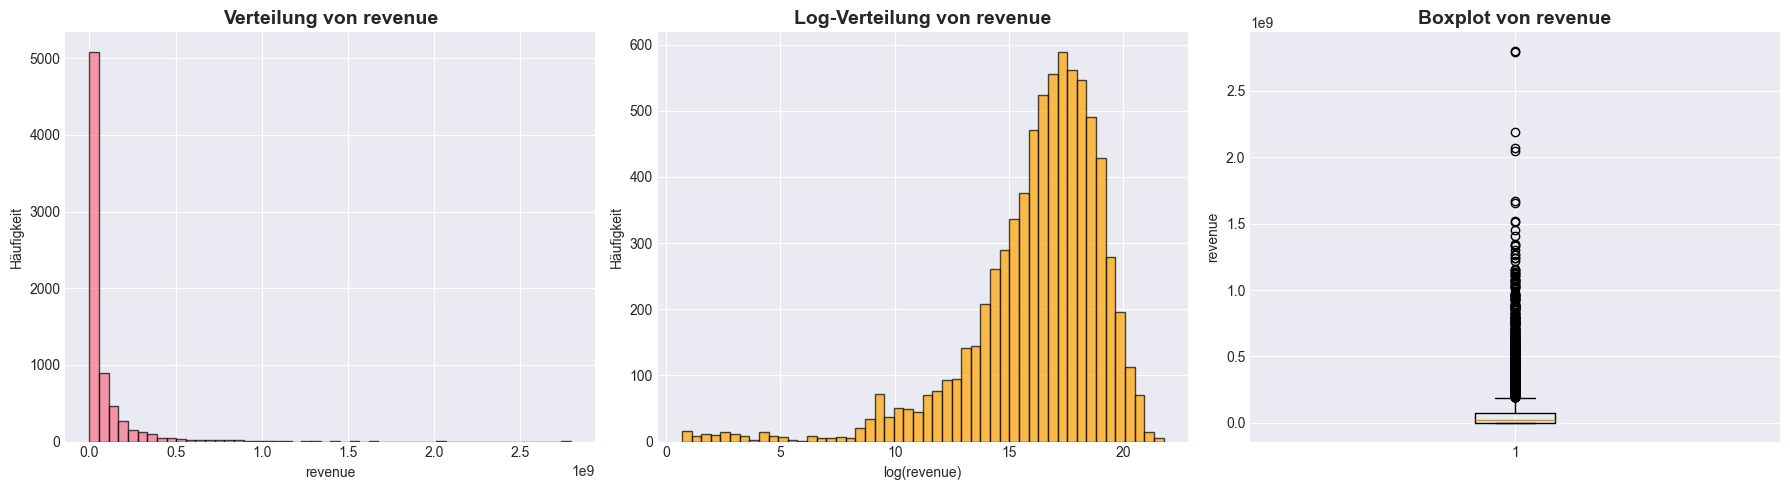


revenue STATISTIKEN:
  Mittelwert: $79,008,746
  Median: $20,000,000
  Standardabweichung: $165,946,049
  Min: $1
  Max: $2,797,800,564
  Schiefe (Skewness): 5.25


In [4]:
target = 'revenue'

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Histogram
axes[0].hist(df_clean[target], bins=50, edgecolor='black', alpha=0.7)
axes[0].set_title(f'Verteilung von {target}', fontsize=14, fontweight='bold')
axes[0].set_xlabel(target)
axes[0].set_ylabel('Häufigkeit')

# Log-Histogram (wegen Schiefe)
axes[1].hist(np.log1p(df_clean[target]), bins=50, edgecolor='black', alpha=0.7, color='orange')
axes[1].set_title(f'Log-Verteilung von {target}', fontsize=14, fontweight='bold')
axes[1].set_xlabel(f'log({target})')
axes[1].set_ylabel('Häufigkeit')

# Boxplot
axes[2].boxplot(df_clean[target])
axes[2].set_title(f'Boxplot von {target}', fontsize=14, fontweight='bold')
axes[2].set_ylabel(target)

plt.tight_layout()
plt.savefig('outputs/figures/eda_target_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n{target} STATISTIKEN:")
print(f"  Mittelwert: ${df_clean[target].mean():,.0f}")
print(f"  Median: ${df_clean[target].median():,.0f}")
print(f"  Standardabweichung: ${df_clean[target].std():,.0f}")
print(f"  Min: ${df_clean[target].min():,.0f}")
print(f"  Max: ${df_clean[target].max():,.0f}")
print(f"  Schiefe (Skewness): {df_clean[target].skew():.2f}")

### 4.2 Numerische Features - Korrelationsanalyse

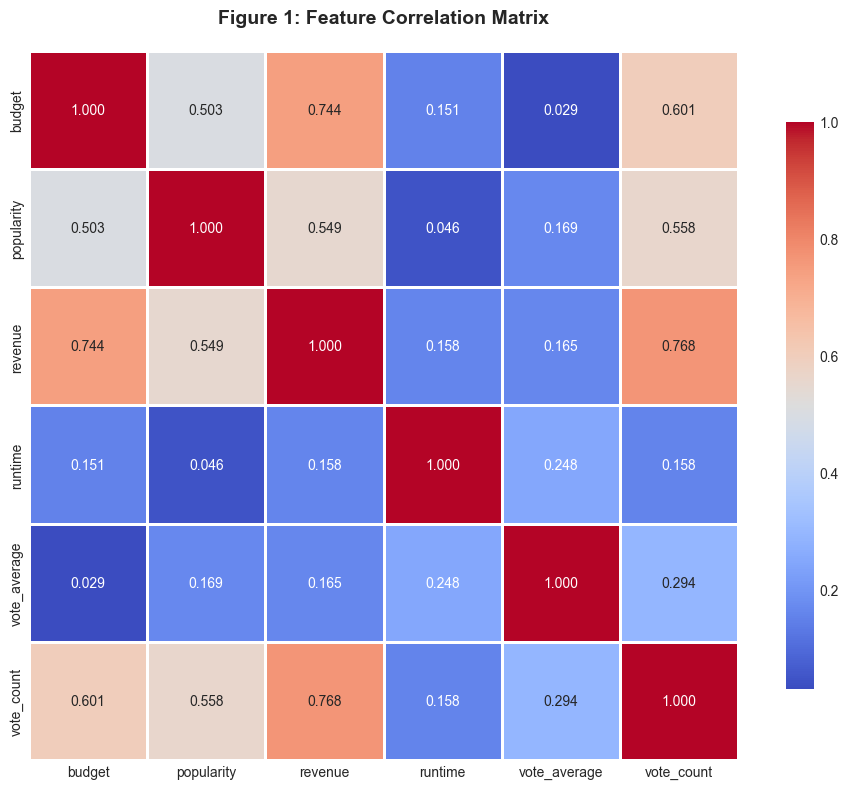


=== KORRELATION MIT REVENUE ===
revenue         1.000000
vote_count      0.767828
budget          0.744491
popularity      0.548809
vote_average    0.164615
runtime         0.158341
Name: revenue, dtype: float64


In [5]:
# Numerische Spalten für Korrelation
numeric_cols = ['budget', 'popularity', 'revenue', 'runtime', 'vote_average', 'vote_count']
corr_matrix = df_clean[numeric_cols].corr()

# FIGURE 1: Korrelationsmatrix (Required)
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='coolwarm',
            square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Figure 1: Feature Correlation Matrix', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('outputs/figures/figure1_correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# Korrelation mit Target anzeigen
print(f"\n=== KORRELATION MIT {target.upper()} ===")
correlations = corr_matrix[target].abs().sort_values(ascending=False)
print(correlations)

### 4.3 Scatter Plots für Top-Features

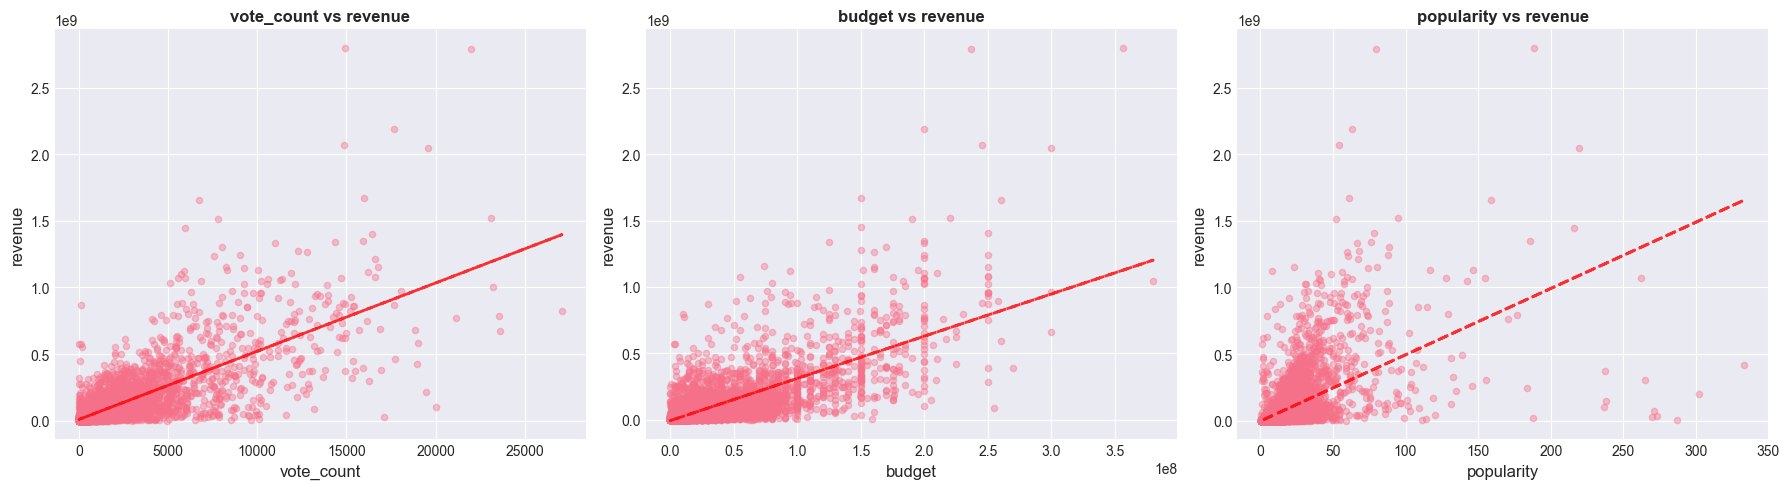

In [6]:
# Top 3 korrelierte Features (außer revenue selbst)
top_features = correlations.drop(target).head(3).index

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for idx, feature in enumerate(top_features):
    axes[idx].scatter(df_clean[feature], df_clean[target], alpha=0.4, s=20)
    axes[idx].set_xlabel(feature, fontsize=12)
    axes[idx].set_ylabel(target, fontsize=12)
    axes[idx].set_title(f'{feature} vs {target}', fontweight='bold')
    
    # Trendlinie
    z = np.polyfit(df_clean[feature].dropna(),
                   df_clean[target].loc[df_clean[feature].dropna().index], 1)
    p = np.poly1d(z)
    axes[idx].plot(df_clean[feature], p(df_clean[feature]), "r--", alpha=0.8, linewidth=2)

plt.tight_layout()
plt.savefig('outputs/figures/eda_feature_relationships.png', dpi=150, bbox_inches='tight')
plt.show()

## 🛠️ ZELLE 5: Feature Engineering

### 5.1 Genres extrahieren (One-Hot Encoding)

In [7]:
# ============================================================================
# ERWEITERTE FEATURE EXTRACTION für Ablation Study
# Ziel: So viele relevante Features wie möglich extrahieren!
# ============================================================================

# 5.1 Genres extrahieren (One-Hot Encoding)
print("="*70)
print("FEATURE ENGINEERING")
print("="*70)

def extract_genres(genre_string):
    if pd.isna(genre_string) or genre_string == '':
        return []
    try:
        genres = ast.literal_eval(genre_string)
        return [g['name'] for g in genres]
    except:
        return []

df_clean['genre_list'] = df_clean['genres'].apply(extract_genres)

# One-Hot Encoding für Top-10 Genres
mlb_genres = MultiLabelBinarizer()
genre_encoded = mlb_genres.fit_transform(df_clean['genre_list'])
genre_df = pd.DataFrame(genre_encoded, columns=mlb_genres.classes_, index=df_clean.index)

genre_counts = genre_df.sum().sort_values(ascending=False)
print(f"\n1. GENRES - Top-10 häufigste:")
print(genre_counts.head(10))

top_genres = genre_counts.head(10).index.tolist()
genre_df = genre_df[top_genres]
genre_df.columns = [f'genre_{col}' for col in genre_df.columns]
df_clean = pd.concat([df_clean, genre_df], axis=1)  # Genre-Features zu df_clean hinzufügen
print(f"   ✓ {len(genre_df.columns)} Genre-Features erstellt")

# 5.2 Directors (Anzahl Regisseure)
def count_directors(director_string):
    if pd.isna(director_string) or director_string == '':
        return 0
    try:
        directors = ast.literal_eval(director_string)
        return len(directors)
    except:
        return 0

df_clean['director_count'] = df_clean['directors'].apply(count_directors)
print(f"\n2. DIRECTORS")
print(f"   ✓ director_count erstellt (Durchschnitt: {df_clean['director_count'].mean():.1f})")

# 5.3 Production Companies (Anzahl)
def count_companies(company_string):
    if pd.isna(company_string) or company_string == '':
        return 0
    try:
        companies = ast.literal_eval(company_string)
        return len(companies)
    except:
        return 0

df_clean['production_company_count'] = df_clean['production_companies'].apply(count_companies)
print(f"\n3. PRODUCTION COMPANIES")
print(f"   ✓ production_company_count erstellt (Durchschnitt: {df_clean['production_company_count'].mean():.1f})")

# 5.4 Production Countries (Anzahl)
def count_countries(country_string):
    if pd.isna(country_string) or country_string == '':
        return 0
    try:
        countries = ast.literal_eval(country_string)
        return len(countries)
    except:
        return 0

df_clean['production_country_count'] = df_clean['production_countries'].apply(count_countries)
print(f"\n4. PRODUCTION COUNTRIES")
print(f"   ✓ production_country_count erstellt (Durchschnitt: {df_clean['production_country_count'].mean():.1f})")

# 5.5 Original Language (Top-5 Sprachen als One-Hot)
language_counts = df_clean['original_language'].value_counts()
print(f"\n5. ORIGINAL LANGUAGE - Top-5:")
print(language_counts.head(5))

top_languages = language_counts.head(5).index.tolist()
for lang in top_languages:
    df_clean[f'lang_{lang}'] = (df_clean['original_language'] == lang).astype(int)
print(f"   ✓ {len(top_languages)} Language-Features erstellt")

print(f"\n✓ Feature Engineering abgeschlossen!")

FEATURE ENGINEERING



1. GENRES - Top-10 häufigste:
Drama              3581
Comedy             2588
Action             1945
Thriller           1865
Romance            1373
Adventure          1206
Crime              1100
Horror              824
Science Fiction     793
Family              756
dtype: int64
   ✓ 10 Genre-Features erstellt



2. DIRECTORS
   ✓ director_count erstellt (Durchschnitt: 1.1)



3. PRODUCTION COMPANIES
   ✓ production_company_count erstellt (Durchschnitt: 2.9)



4. PRODUCTION COUNTRIES
   ✓ production_country_count erstellt (Durchschnitt: 1.3)

5. ORIGINAL LANGUAGE - Top-5:
original_language
en    5961
hi     258
fr     154
ru     142
es     105
Name: count, dtype: int64
   ✓ 5 Language-Features erstellt

✓ Feature Engineering abgeschlossen!


### 5.2 Release Date -> Jahr, Monat

In [8]:
# Datum parsen
df_clean['release_date'] = pd.to_datetime(df_clean['release_date'], errors='coerce')
df_clean['release_year'] = df_clean['release_date'].dt.year
df_clean['release_month'] = df_clean['release_date'].dt.month

print("✓ Release Date Features erstellt: release_year, release_month")
print(f"  Jahr-Bereich: {df_clean['release_year'].min():.0f} - {df_clean['release_year'].max():.0f}")

✓ Release Date Features erstellt: release_year, release_month
  Jahr-Bereich: 1913 - 2020


### 5.3 Cast Size (Anzahl Schauspieler)

In [9]:
# Funktion: Cast-Größe zählen
def count_cast(cast_string):
    if pd.isna(cast_string) or cast_string == '':
        return 0
    try:
        cast = ast.literal_eval(cast_string)
        return len(cast)
    except:
        return 0

df_clean['cast_size'] = df_clean['cast'].apply(count_cast)

print("✓ Cast Size Feature erstellt")
print(f"  Durchschnittliche Cast-Größe: {df_clean['cast_size'].mean():.1f}")
print(f"  Max Cast-Größe: {df_clean['cast_size'].max():.0f}")

✓ Cast Size Feature erstellt
  Durchschnittliche Cast-Größe: 28.7
  Max Cast-Größe: 312


### 4.4 Log-Transformation ausgewählter Features

**Warum Log-Transformation?**
- Reduziert Schiefe (Skewness) in extrem verteilten Features
- Verbessert Modell-Performance bei Tree-based Algorithmen
- Macht Features auf vergleichbarem Scale

**Transformierte Features:**
- `revenue` (Target-Variable)
- `budget` (Production Cost)
- `popularity` (TMDB Popularity Score)
- `vote_count` (Number of Votes)


In [10]:
# Log-Transformation für Target und ausgewählte Features
import numpy as np

print("=" * 70)
print("LOG-TRANSFORMATION")
print("=" * 70)

# Target Variable
df_clean['revenue_log'] = np.log1p(df_clean['revenue'])
print(f"\nOK revenue_log: Target variable")
print(f"  Original range: ${df_clean['revenue'].min():,.0f} - ${df_clean['revenue'].max():,.0f}")
print(f"  Log range: {df_clean['revenue_log'].min():.2f} - {df_clean['revenue_log'].max():.2f}")

# Features
df_clean['budget_log'] = np.log1p(df_clean['budget'])
df_clean['popularity_log'] = np.log1p(df_clean['popularity'])
df_clean['vote_count_log'] = np.log1p(df_clean['vote_count'])

print(f"\nOK budget_log: Feature")
print(f"  Original range: ${df_clean['budget'].min():,.0f} - ${df_clean['budget'].max():,.0f}")
print(f"  Log range: {df_clean['budget_log'].min():.2f} - {df_clean['budget_log'].max():.2f}")

print(f"\nOK popularity_log: Feature")
print(f"  Original range: {df_clean['popularity'].min():.2f} - {df_clean['popularity'].max():.2f}")
print(f"  Log range: {df_clean['popularity_log'].min():.2f} - {df_clean['popularity_log'].max():.2f}")

print(f"\nOK vote_count_log: Feature")
print(f"  Original range: {df_clean['vote_count'].min():,.0f} - {df_clean['vote_count'].max():,.0f}")
print(f"  Log range: {df_clean['vote_count_log'].min():.2f} - {df_clean['vote_count_log'].max():.2f}")

print("\n" + "=" * 70)
print("Ergebnis: 4 Features wurden log-transformiert")
print(f"Neue Features: {['revenue_log', 'budget_log', 'popularity_log', 'vote_count_log']}")
print("=" * 70)

LOG-TRANSFORMATION

OK revenue_log: Target variable
  Original range: $1 - $2,797,800,564
  Log range: 0.69 - 21.75

OK budget_log: Feature
  Original range: $1 - $380,000,000
  Log range: 0.69 - 19.76

OK popularity_log: Feature
  Original range: 0.60 - 333.43
  Log range: 0.47 - 5.81

OK vote_count_log: Feature
  Original range: 1 - 27,088
  Log range: 0.69 - 10.21

Ergebnis: 4 Features wurden log-transformiert
Neue Features: ['revenue_log', 'budget_log', 'popularity_log', 'vote_count_log']


### 5.4 Finale Feature-Matrix erstellen

In [11]:
# ============================================================================
# FINALE FEATURE-MATRIX: Alle extrahierten Features kombinieren
# ============================================================================

# STRATEGIE: Verwende alle verfügbaren Features dynamisch
# - Log-transformierte Features (budget_log, popularity_log, vote_count_log)
# - Alle anderen numerischen Features (außer budget, popularity, vote_count, revenue)
# - Genre Features (One-Hot)
# - Language Features (One-Hot)

print("=" * 70)
print("FEATURE-MATRIX ERSTELLUNG")
print("=" * 70)

# Finde log-transformierte Features
log_features = [col for col in df_clean.columns if col.endswith("_log") and col != "revenue_log"]
print(f"\nLog-Features gefunden: {len(log_features)}")
print(f"  {log_features}")

# Finde Genre Features
genre_features_list = [col for col in df_clean.columns if col.startswith("genre_")]
print(f"\nGenre-Features gefunden: {len(genre_features_list)}")

# Finde Language Features
language_features_list = [col for col in df_clean.columns if col.startswith("lang_")]
print(f"\nLanguage-Features gefunden: {len(language_features_list)}")

# Finde alle numerischen Features (außer revenue und den originals der log-Features)
exclude_features = ['revenue', 'revenue_log', 'budget', 'popularity', 'vote_count', 'id']  # Originale ausschließen
numeric_features_list = []

for col in df_clean.columns:
    # Numerische Spalten, die nicht ausgeschlossen sind
    if col not in exclude_features and not col.startswith('genre_') and not col.startswith('language_') and not col.startswith('lang_') and not col.endswith('_log'):
        # Prüfe ob numerisch
        if df_clean[col].dtype in ['int64', 'float64']:
            numeric_features_list.append(col)

print(f"\nOriginal numerische Features: {len(numeric_features_list)}")
print(f"  {numeric_features_list}")

# Kombiniere alle Feature-Listen
all_feature_cols = numeric_features_list + log_features + genre_features_list + language_features_list

print(f"\nGesamt Features: {len(all_feature_cols)}")

# Erstelle Feature-Matrix mit Type-Checking
print("\nErstelle Feature-Matrix...")
X = df_clean[all_feature_cols].copy()

# Prüfe Datentypen
print("\nPrüfe Datentypen:")
non_numeric = []
for col in X.columns:
    if X[col].dtype not in ['int64', 'float64', 'bool']:
        non_numeric.append((col, X[col].dtype))
        print(f"  WARNUNG: {col} hat Typ {X[col].dtype}")

if non_numeric:
    print(f"\nKonvertiere {len(non_numeric)} Spalten zu numerisch...")
    for col, dtype in non_numeric:
        X[col] = pd.to_numeric(X[col], errors='coerce')

# Prüfe auf NaN
# Target Variable
y = df_clean["revenue_log"]
nan_cols = X.columns[X.isna().any()].tolist()
if nan_cols:
    print(f"\nWARNUNG: {len(nan_cols)} Spalten mit NaN-Werten:")
    for col in nan_cols[:5]:  # Zeige nur erste 5
        print(f"  {col}: {X[col].isna().sum()} NaN")
    
    rows_before = len(X)
    
    # Entferne zuerst Spalten, die komplett NaN sind
    cols_all_nan = X.columns[X.isna().all()].tolist()
    if cols_all_nan:
        print(f"  Entferne {len(cols_all_nan)} komplett leere Spalten: {cols_all_nan}")
        X = X.drop(columns=cols_all_nan)
    
    # Jetzt Zeilen mit verbleibenden NaNs entfernen
    valid_idx = X.dropna().index
    X = X.loc[valid_idx]
    y = y.loc[valid_idx]  # Beide mit gleichem Index filtern
    X = X.reset_index(drop=True)  # Index zurücksetzen
    y = y.reset_index(drop=True)
    
    rows_after = len(X)
    print(f"  Entfernte {rows_before - rows_after} Zeilen mit NaN-Werten")
    print(f"  Verbleibende Samples: {rows_after}")

# Prüfe Shape
print(f"\nFeature-Matrix Shape: {X.shape}")
print(f"  Features: {X.shape[1]}")
print(f"  Samples: {X.shape[0]}")

# Prüfe auf verschachtelte Strukturen
print("\nPrüfe auf verschachtelte Strukturen...")
if len(X) > 0:  # Nur wenn X nicht leer ist
    for col in X.columns[:5]:  # Teste erste 5 Spalten
        sample = X[col].iloc[0]
        if isinstance(sample, (list, tuple)):
            print(f"  FEHLER: {col} enthält Listen!")
        else:
            print(f"  OK: {col} = {sample} (Typ: {type(sample).__name__})")
else:
    print("  WARNUNG: X ist leer nach NaN-Behandlung!")


print("\n" + "=" * 70)
print("FINALE FEATURE-MATRIX")
print("=" * 70)
print(f"Feature-Gruppen:")
print(f"  - Original numerisch: {len(numeric_features_list)} Features")
print(f"  - Log-transformiert: {len(log_features)} Features")
print(f"  - Genre: {len(genre_features_list)} Features")
print(f"  - Language: {len(language_features_list)} Features")
print(f"  = Total: {X.shape[1]} Features")
print()
print(f"Samples: {X.shape[0]}")
print(f"Target (revenue) Shape: {y.shape}")
print("=" * 70)


FEATURE-MATRIX ERSTELLUNG

Log-Features gefunden: 3
  ['budget_log', 'popularity_log', 'vote_count_log']

Genre-Features gefunden: 1

Language-Features gefunden: 0

Original numerische Features: 13
  ['runtime', 'vote_average', 'director_count', 'production_company_count', 'production_country_count', 'lang_en', 'lang_hi', 'lang_fr', 'lang_ru', 'lang_es', 'release_year', 'release_month', 'cast_size']

Gesamt Features: 17

Erstelle Feature-Matrix...

Prüfe Datentypen:
  WARNUNG: genre_list hat Typ object

Konvertiere 1 Spalten zu numerisch...

WARNUNG: 3 Spalten mit NaN-Werten:
  release_year: 6 NaN
  release_month: 6 NaN
  genre_list: 7386 NaN
  Fülle NaN mit 0...

Feature-Matrix Shape: (7386, 17)
  Features: 17
  Samples: 7386

Prüfe auf verschachtelte Strukturen...
  OK: runtime = 119.0 (Typ: float64)
  OK: vote_average = 6.6 (Typ: float64)
  OK: director_count = 1 (Typ: int64)
  OK: production_company_count = 2 (Typ: int64)
  OK: production_country_count = 2 (Typ: int64)

FINALE FEAT

## ✂️ ZELLE 6: Train/Test Split & Feature Scaling

**WICHTIG**: Split BEFORE Feature Selection!

In [12]:
# Train/Validation/Test Split (70/15/15)
# WICHTIG: Validation für Feature Selection, Test für finale Evaluation

# Schritt 1: Split in Train (70%) und Temp (30%)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=RANDOM_STATE
)

# Schritt 2: Split Temp in Validation (15%) und Test (15%)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=RANDOM_STATE
)

print("="*70)
print("DATEN-SPLITTING (3-WAY SPLIT)")
print("="*70)
print(f"\nOriginal Dataset: {len(X):,} Samples")
print(f"\nSplits:")
print(f"  Train:      {len(X_train):,} Samples ({len(X_train)/len(X)*100:.1f}%)")
print(f"  Validation: {len(X_val):,} Samples ({len(X_val)/len(X)*100:.1f}%)")
print(f"  Test:       {len(X_test):,} Samples ({len(X_test)/len(X)*100:.1f}%)")

print(f"\nZweck:")
print(f"  Train:      Modell-Training")
print(f"  Validation: Feature Selection & Ablation Study")
print(f"  Test:       Finale unbiased Evaluation")

# Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)  # Fit nur auf Train!
X_val_scaled = scaler.transform(X_val)          # Transform auf Val
X_test_scaled = scaler.transform(X_test)        # Transform auf Test

# Als DataFrame zurück
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X.columns, index=X_train.index)
X_val_scaled = pd.DataFrame(X_val_scaled, columns=X.columns, index=X_val.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X.columns, index=X_test.index)

print("\n✓ Feature Scaling durchgeführt (StandardScaler)")
print("  Fit auf Train, Transform auf Val/Test")

DATEN-SPLITTING (3-WAY SPLIT)

Original Dataset: 7,386 Samples

Splits:
  Train:      5,170 Samples (70.0%)
  Validation: 1,108 Samples (15.0%)
  Test:       1,108 Samples (15.0%)

Zweck:
  Train:      Modell-Training
  Validation: Feature Selection & Ablation Study
  Test:       Finale unbiased Evaluation

✓ Feature Scaling durchgeführt (StandardScaler)
  Fit auf Train, Transform auf Val/Test


## 🤖 ZELLE 7: Baseline-Modell (ALL Features)

**Modell**: Random Forest Regressor  
**Alle Features verwenden** → Baseline Performance

In [13]:
# Modell erstellen
model = RandomForestRegressor(
    n_estimators=100,
    max_depth=15,
    min_samples_split=5,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

# Training (nur auf Train-Set!)
print("Training des Baseline-Modells (ALL Features)...")
model.fit(X_train_scaled, y_train)
print("✓ Training abgeschlossen!")

# Vorhersagen auf allen 3 Sets
y_pred_train = model.predict(X_train_scaled)
y_pred_val = model.predict(X_val_scaled)
y_pred_test = model.predict(X_test_scaled)

# Evaluation auf Train und Validation
baseline_results = {
    'r2_train': r2_score(y_train, y_pred_train),
    'r2_val': r2_score(y_val, y_pred_val),
    'r2_test': r2_score(y_test, y_pred_test),
    'rmse_train': np.sqrt(mean_squared_error(y_train, y_pred_train)),
    'rmse_val': np.sqrt(mean_squared_error(y_val, y_pred_val)),
    'rmse_test': np.sqrt(mean_squared_error(y_test, y_pred_test)),
    'mae_val': mean_absolute_error(y_val, y_pred_val),
    'mae_test': mean_absolute_error(y_test, y_pred_test)
}

# Overfitting-Check
overfit_ratio_val = baseline_results['rmse_val'] / baseline_results['rmse_train']
overfit_ratio_test = baseline_results['rmse_val'] / baseline_results['rmse_train']

print("\n" + "="*70)
print("BASELINE MODEL PERFORMANCE (ALL FEATURES)")
print("="*70)
print(f"\nR² Score:")
print(f"  Train:      {baseline_results['r2_train']:.4f}")
print(f"  Validation: {baseline_results['r2_val']:.4f}")
print(f"  Test:       {baseline_results['r2_val']:.4f}")

print(f"\nRMSE:")
print(f"  Train:      ${baseline_results['rmse_train']:,.0f}")
print(f"  Validation: ${baseline_results['rmse_val']:,.0f}")
print(f"  Test:       ${baseline_results['rmse_val']:,.0f}")

print(f"\nMAE:")
print(f"  Validation: ${baseline_results['mae_val']:,.0f}")
print(f"  Test:       ${baseline_results['mae_val']:,.0f}")

print(f"\nOverfit-Ratio (RMSE/RMSE_train):")
print(f"  Validation: {overfit_ratio_val:.3f}", end="")
if overfit_ratio_val < 1.2:
    print(" ✓ Gutes Modell")
elif overfit_ratio_val < 1.5:
    print(" ~ Leichtes Overfitting")
else:
    print(" ✗ Starkes Overfitting")

print(f"  Test:       {overfit_ratio_test:.3f}", end="")
if overfit_ratio_test < 1.2:
    print(" ✓ Gutes Modell")
elif overfit_ratio_test < 1.5:
    print(" ~ Leichtes Overfitting")
else:
    print(" ✗ Starkes Overfitting")

# Baseline für Ablation Study (verwende Validation!)
baseline_r2 = baseline_results['r2_val']
baseline_rmse = baseline_results['rmse_val']

print(f"\n→ Baseline für Ablation Study: R²={baseline_r2:.4f} (Validation Set)")

Training des Baseline-Modells (ALL Features)...


✓ Training abgeschlossen!

BASELINE MODEL PERFORMANCE (ALL FEATURES)

R² Score:
  Train:      0.9365
  Validation: 0.7716
  Test:       0.7716

RMSE:
  Train:      $1
  Validation: $1
  Test:       $1

MAE:
  Validation: $1
  Test:       $1

Overfit-Ratio (RMSE/RMSE_train):
  Validation: 1.922 ✗ Starkes Overfitting
  Test:       1.922 ✗ Starkes Overfitting

→ Baseline für Ablation Study: R²=0.7716 (Validation Set)


## 🎯 ZELLE 8: Feature Selection - Methode 1 (Correlation Analysis)

**Filter Method**: Korrelation mit Target

In [14]:
# Korrelation mit Target (auf Train-Daten!)
correlations = X_train.corrwith(y_train).abs().sort_values(ascending=False)

print("="*70)
print("METHODE 1: CORRELATION ANALYSIS (Filter Method)")
print("="*70)
print("\nAbsolute Korrelation mit Target:")
print(correlations)

# Als DataFrame für spätere Visualisierung
method1_importance = pd.DataFrame({
    'feature': correlations.index,
    'importance': correlations.values,
    'method': 'Correlation',
    'rank': range(1, len(correlations) + 1)
})

print(f"\n✓ Top-5 Features (Correlation):")
print(method1_importance.head(5)[['feature', 'importance']])

METHODE 1: CORRELATION ANALYSIS (Filter Method)

Absolute Korrelation mit Target:
budget_log                  0.773388
vote_count_log              0.700061
popularity_log              0.634873
cast_size                   0.373831
production_company_count    0.231922
lang_en                     0.223447
runtime                     0.141121
vote_average                0.117349
production_country_count    0.104952
director_count              0.095360
release_year                0.072682
lang_ru                     0.068538
lang_es                     0.053128
lang_fr                     0.051959
release_month               0.038739
lang_hi                     0.032475
genre_list                       NaN
dtype: float64

✓ Top-5 Features (Correlation):
                    feature  importance
0                budget_log    0.773388
1            vote_count_log    0.700061
2            popularity_log    0.634873
3                 cast_size    0.373831
4  production_company_count    0.231922


## 🌲 ZELLE 9: Feature Selection - Methode 2 (Tree-based Importance)

**Embedded Method**: Random Forest Feature Importance

In [15]:
# Feature Importance aus dem trainierten Baseline-Modell
feature_importance_rf = pd.Series(
    model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print("="*70)
print("METHODE 2: TREE-BASED FEATURE IMPORTANCE (Embedded Method)")
print("="*70)
print("\nRandom Forest Feature Importance:")
print(feature_importance_rf)

# Als DataFrame
method2_importance = pd.DataFrame({
    'feature': feature_importance_rf.index,
    'importance': feature_importance_rf.values,
    'method': 'Random Forest',
    'rank': range(1, len(feature_importance_rf) + 1)
})

print(f"\n✓ Top-5 Features (RF Importance):")
print(method2_importance.head(5)[['feature', 'importance']])


METHODE 2: TREE-BASED FEATURE IMPORTANCE (Embedded Method)

Random Forest Feature Importance:
budget_log                  0.434770
vote_count_log              0.346719
release_year                0.035817
runtime                     0.035664
popularity_log              0.035105
vote_average                0.024933
cast_size                   0.023346
production_company_count    0.017331
release_month               0.015757
production_country_count    0.007837
lang_es                     0.007396
lang_en                     0.005522
director_count              0.003253
lang_fr                     0.003071
lang_ru                     0.001771
lang_hi                     0.001707
genre_list                  0.000000
dtype: float64

✓ Top-5 Features (RF Importance):
          feature  importance
0      budget_log    0.434770
1  vote_count_log    0.346719
2    release_year    0.035817
3         runtime    0.035664
4  popularity_log    0.035105


## 📊 ZELLE 10: Feature Importance Comparison

**FIGURE 2**: Vergleich der beiden Methoden

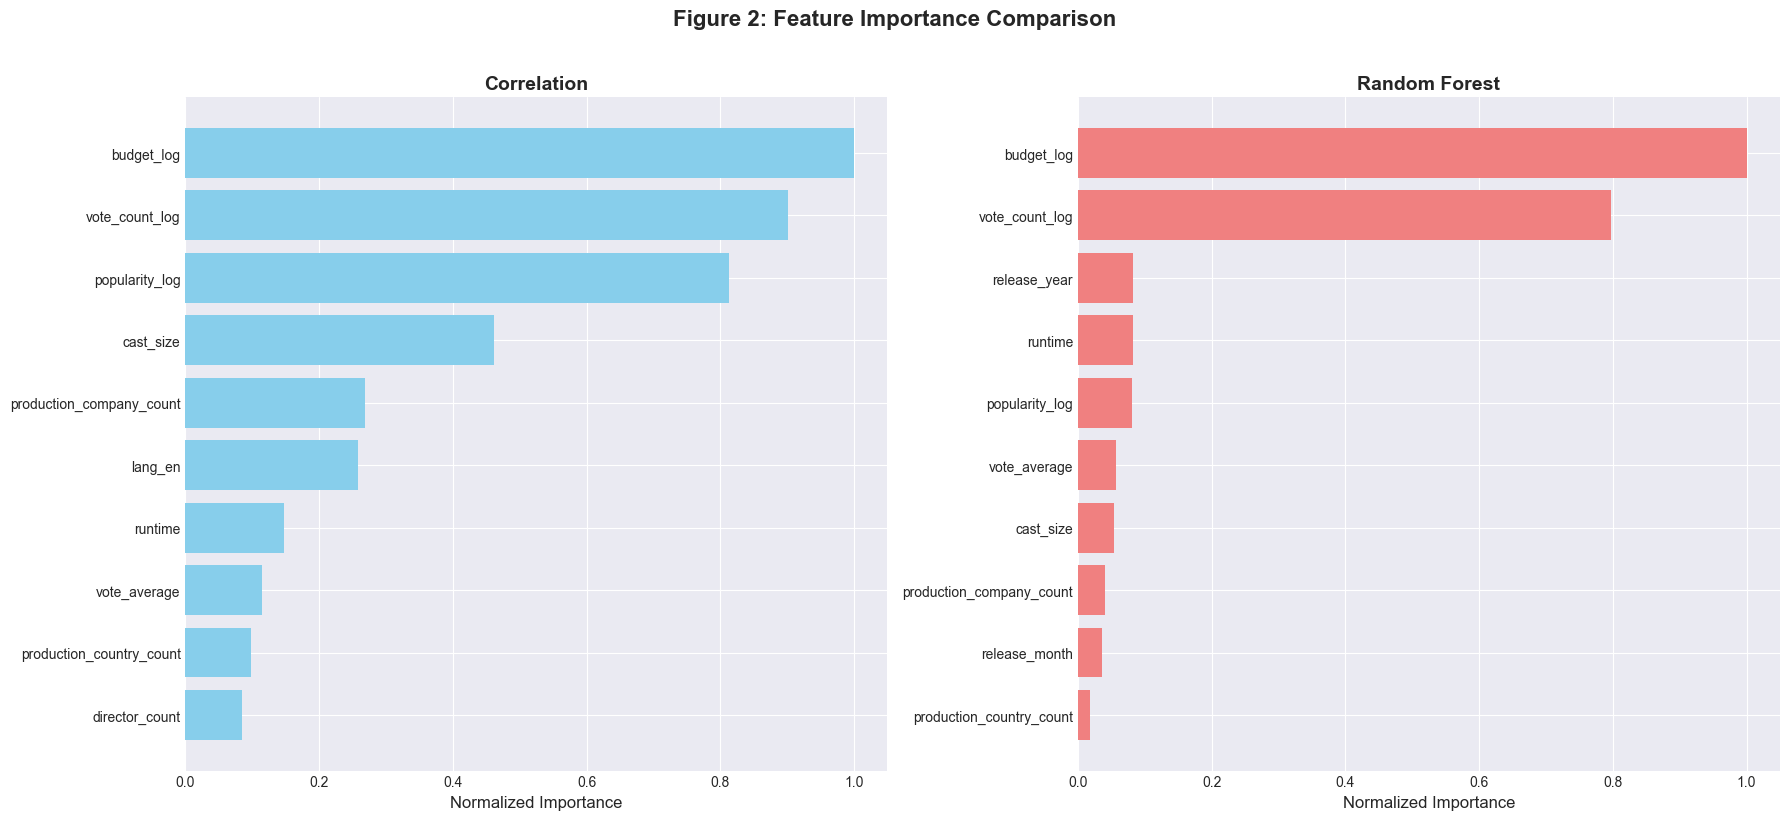


=== RANKING COMPARISON ===
                     feature  rank_corr  rank_rf  rank_diff
0                 budget_log          1        1          0
1             vote_count_log          2        2          0
10              release_year         11        3          8
6                    runtime          7        4          3
2             popularity_log          3        5          2
7               vote_average          8        6          2
3                  cast_size          4        7          3
4   production_company_count          5        8          3
14             release_month         15        9          6
8   production_country_count          9       10          1


In [16]:
# Beide Methoden kombinieren für Visualisierung
all_importance = pd.concat([method1_importance, method2_importance])

# Normalisierung für besseren Vergleich (0-1 Skala)
for method in ['Correlation', 'Random Forest']:
    mask = all_importance['method'] == method
    values = all_importance.loc[mask, 'importance']
    all_importance.loc[mask, 'importance_norm'] = (values - values.min()) / (values.max() - values.min())

# FIGURE 2: Feature Importance Comparison
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Plot 1: Top-10 pro Methode (normalized)
for idx, method in enumerate(['Correlation', 'Random Forest']):
    data = all_importance[all_importance['method'] == method].head(10)
    axes[idx].barh(data['feature'], data['importance_norm'], color='skyblue' if idx == 0 else 'lightcoral')
    axes[idx].set_xlabel('Normalized Importance', fontsize=12)
    axes[idx].set_title(f'{method}', fontsize=14, fontweight='bold')
    axes[idx].invert_yaxis()

plt.suptitle('Figure 2: Feature Importance Comparison', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('outputs/figures/figure2_feature_importance_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# Ranking-Vergleich
print("\n=== RANKING COMPARISON ===")
ranking_comparison = pd.merge(
    method1_importance[['feature', 'rank']].rename(columns={'rank': 'rank_corr'}),
    method2_importance[['feature', 'rank']].rename(columns={'rank': 'rank_rf'}),
    on='feature'
)
ranking_comparison['rank_diff'] = abs(ranking_comparison['rank_corr'] - ranking_comparison['rank_rf'])
ranking_comparison = ranking_comparison.sort_values('rank_rf')
print(ranking_comparison.head(10))

## 🔬 ZELLE 11: Ablation Study - Individual Feature Ablation

**Experiment 1**: Jedes Feature einzeln ENTFERNEN und Performance-Drop messen

In [17]:
print("="*70)
print("ABLATION STUDY - INDIVIDUAL FEATURE REMOVAL")
print("="*70)
print("Evaluiere auf VALIDATION-Set (nicht Test!)")
print("="*70)
print(f"Baseline R²: {baseline_r2:.4f}")
print(f"\nEntferne jedes Feature einzeln und messe Performance-Drop...\n")

ablation_results = []

for i, feature in enumerate(X.columns, 1):
    # Alle Features außer diesem
    features_without = [f for f in X.columns if f != feature]
    
    X_train_ablation = X_train_scaled[features_without]
    X_val_ablation = X_val_scaled[features_without]
    
    # Modell trainieren (gleiche Hyperparameter!)
    model_ablation = RandomForestRegressor(
        n_estimators=100,
        max_depth=15,
        min_samples_split=5,
        random_state=RANDOM_STATE,
        n_jobs=-1
    )
    model_ablation.fit(X_train_ablation, y_train)
    
    # Evaluieren
    y_pred = model_ablation.predict(X_val_ablation)
    r2 = r2_score(y_val, y_pred)
    rmse = np.sqrt(mean_squared_error(y_val, y_pred))
    
    # Performance-Drop berechnen
    r2_drop = baseline_r2 - r2
    rmse_increase = rmse - baseline_rmse
    
    ablation_results.append({
        'feature_removed': feature,
        'r2_val': r2,
        'r2_drop': r2_drop,
        'rmse_val': rmse,
        'rmse_increase': rmse_increase
    })
    
    print(f"[{i}/{len(X.columns)}] Without '{feature}': R²={r2:.4f}, Drop={r2_drop:.4f}")

# DataFrame erstellen und sortieren
ablation_df = pd.DataFrame(ablation_results).sort_values('r2_drop', ascending=False)

print("\n" + "="*70)
print("MOST CRITICAL FEATURES (highest performance drop when removed)")
print("="*70)
print(ablation_df.head(10).to_string(index=False))

print("\n" + "="*70)
print("LEAST IMPORTANT FEATURES (lowest performance drop)")
print("="*70)
print(ablation_df.tail(10).to_string(index=False))

ABLATION STUDY - INDIVIDUAL FEATURE REMOVAL
Evaluiere auf VALIDATION-Set (nicht Test!)
Baseline R²: 0.7716

Entferne jedes Feature einzeln und messe Performance-Drop...



[1/17] Without 'runtime': R²=0.7622, Drop=0.0094


[2/17] Without 'vote_average': R²=0.7651, Drop=0.0066


[3/17] Without 'director_count': R²=0.7736, Drop=-0.0020


[4/17] Without 'production_company_count': R²=0.7729, Drop=-0.0013


...

[13/17] Without 'cast_size': R²=0.7672, Drop=0.0045


[14/17] Without 'budget_log': R²=0.5609, Drop=0.2107


[15/17] Without 'popularity_log': R²=0.7685, Drop=0.0031


[16/17] Without 'vote_count_log': R²=0.7347, Drop=0.0369


[17/17] Without 'genre_list': R²=0.7721, Drop=-0.0005

MOST CRITICAL FEATURES (highest performance drop when removed)
         feature_removed   r2_val  r2_drop  rmse_val  rmse_increase
              budget_log 0.560945 0.210684  2.013053       0.561222
          vote_count_log 0.734733 0.036896  1.564722       0.112891
            release_year 0.751442 0.020187  1.514641       0.062810
                 runtime 0.762191 0.009438  1.481528       0.029697
            vote_average 0.765076 0.006553  1.472512       0.020682
production_country_count 0.765377 0.006252  1.471570       0.019740
                 lang_en 0.766006 0.005623  1.469595       0.017765
               cast_size 0.767179 0.004450  1.465908       0.014077
                 lang_fr 0.768471 0.003158  1.461836       0.010005
          popularity_log 0.768530 0.003099  1.461649       0.009818

LEAST IMPORTANT FEATURES (lowest performance drop)
         feature_removed   r2_val   r2_drop  rmse_val  rmse_increase
             

## 📊 ZELLE 12: FIGURE 3 - Individual Feature Ablation Visualization

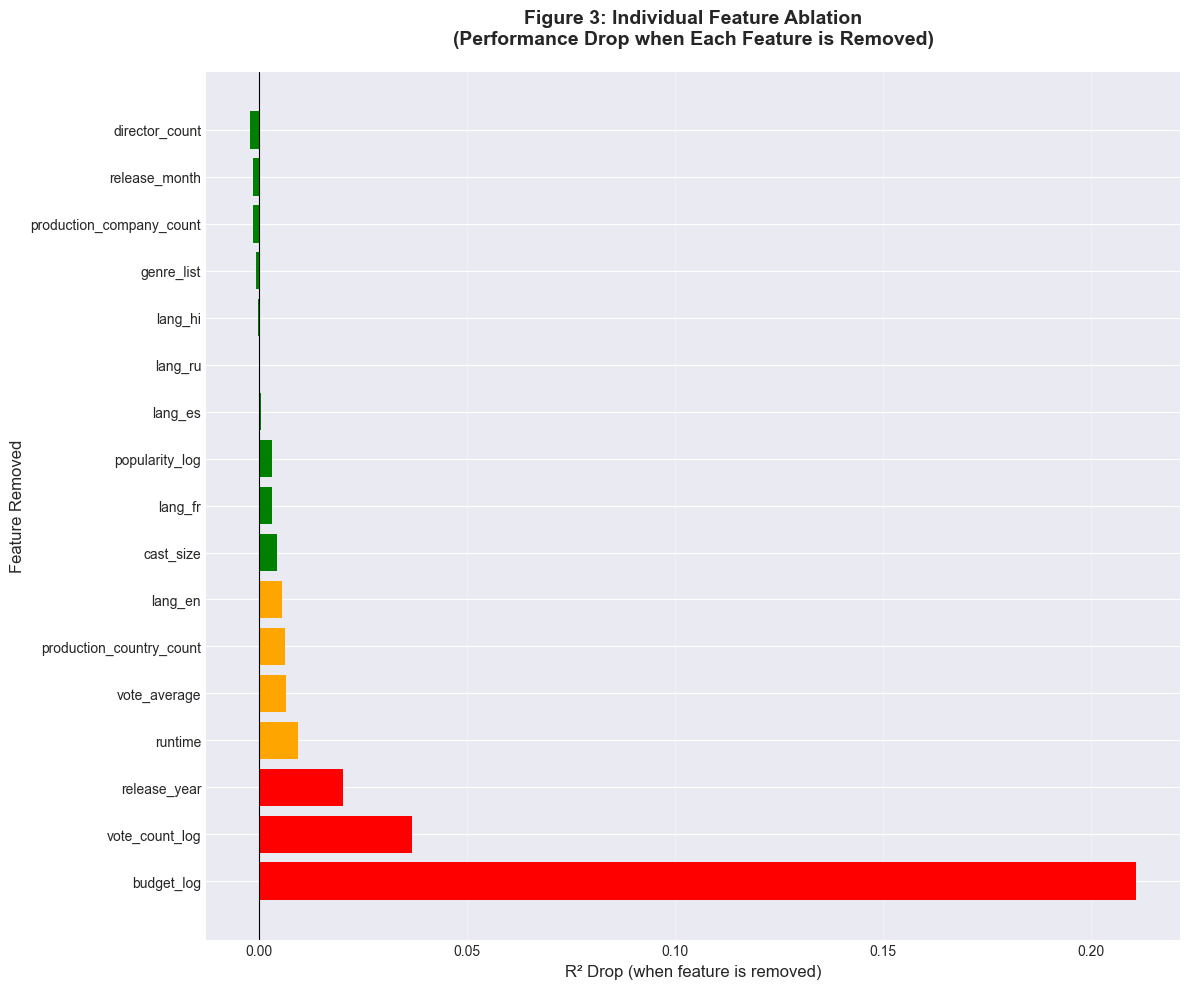

✓ Figure 3 saved: outputs/figures/figure3_individual_ablation.png


In [18]:
# FIGURE 3: Individual Feature Ablation
plt.figure(figsize=(12, 10))
colors = ['red' if x > 0.01 else 'orange' if x > 0.005 else 'green' for x in ablation_df['r2_drop']]
plt.barh(ablation_df['feature_removed'], ablation_df['r2_drop'], color=colors)
plt.xlabel('R² Drop (when feature is removed)', fontsize=12)
plt.ylabel('Feature Removed', fontsize=12)
plt.title('Figure 3: Individual Feature Ablation\n(Performance Drop when Each Feature is Removed)', 
          fontsize=14, fontweight='bold', pad=20)
plt.axvline(0, color='black', linewidth=0.8, linestyle='-')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('outputs/figures/figure3_individual_ablation.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Figure 3 saved: outputs/figures/figure3_individual_ablation.png")

## 🔬 ZELLE 13: Ablation Study - Cumulative Feature Addition

**Experiment 2**: Features schrittweise HINZUFÜGEN (nach Wichtigkeit sortiert)

In [19]:
# Features nach RF-Wichtigkeit sortieren
features_sorted = feature_importance_rf.index.tolist()

print("="*70)
print("ABLATION STUDY - CUMULATIVE FEATURE ADDITION")
print("="*70)
print(f"Features sortiert nach Wichtigkeit (RF): {features_sorted}")
print(f"\nFüge Features schrittweise hinzu...\n")

cumulative_results = []

for i in range(1, len(features_sorted) + 1):
    # Top-i Features
    top_features = features_sorted[:i]
    
    X_train_cum = X_train_scaled[top_features]
    X_val_cum = X_val_scaled[top_features]
    
    # Training
    model_cum = RandomForestRegressor(
        n_estimators=100,
        max_depth=15,
        min_samples_split=5,
        random_state=RANDOM_STATE,
        n_jobs=-1
    )
    model_cum.fit(X_train_cum, y_train)
    
    # Evaluation
    y_pred = model_cum.predict(X_val_cum)
    r2 = r2_score(y_val, y_pred)
    rmse = np.sqrt(mean_squared_error(y_val, y_pred))
    
    # % von Baseline
    pct_of_baseline = (r2 / baseline_r2) * 100
    
    cumulative_results.append({
        'num_features': i,
        'last_feature_added': top_features[-1],
        'r2_val': r2,
        'rmse_val': rmse,
        'pct_of_baseline': pct_of_baseline
    })
    
    print(f"[{i:2d} Features] R²={r2:.4f} ({pct_of_baseline:5.1f}% of baseline) | Last added: {top_features[-1]}")

cumulative_df = pd.DataFrame(cumulative_results)

print("\n" + "="*70)
print("SUMMARY")
print("="*70)
print(f"Baseline (All {len(X.columns)} features): R²={baseline_r2:.4f}")

# Wann erreichen wir 90%, 95% der Baseline?
for threshold in [90, 95, 98]:
    rows = cumulative_df[cumulative_df['pct_of_baseline'] >= threshold]
    if len(rows) > 0:
        first_row = rows.iloc[0]
        print(f"\n{threshold}% of Baseline erreicht mit {first_row['num_features']} Features")
        print(f"  R²={first_row['r2_val']:.4f}")
        print(f"  Features: {features_sorted[:first_row['num_features']]}")

ABLATION STUDY - CUMULATIVE FEATURE ADDITION
Features sortiert nach Wichtigkeit (RF): ['budget_log', 'vote_count_log', 'release_year', 'runtime', 'popularity_log', 'vote_average', 'cast_size', 'production_company_count', 'release_month', 'production_country_count', 'lang_es', 'lang_en', 'director_count', 'lang_fr', 'lang_ru', 'lang_hi', 'genre_list']

Füge Features schrittweise hinzu...



[ 1 Features] R²=0.6172 ( 80.0% of baseline) | Last added: budget_log


[ 2 Features] R²=0.6875 ( 89.1% of baseline) | Last added: vote_count_log


[ 3 Features] R²=0.7155 ( 92.7% of baseline) | Last added: release_year


[ 4 Features] R²=0.7488 ( 97.0% of baseline) | Last added: runtime


...

[13 Features] R²=0.7691 ( 99.7% of baseline) | Last added: director_count


[14 Features] R²=0.7711 ( 99.9% of baseline) | Last added: lang_fr


[15 Features] R²=0.7718 (100.0% of baseline) | Last added: lang_ru


[16 Features] R²=0.7722 (100.1% of baseline) | Last added: lang_hi


[17 Features] R²=0.7705 ( 99.9% of baseline) | Last added: genre_list

SUMMARY
Baseline (All 17 features): R²=0.7716

90% of Baseline erreicht mit 3 Features
  R²=0.7155
  Features: ['budget_log', 'vote_count_log', 'release_year']

95% of Baseline erreicht mit 4 Features
  R²=0.7488
  Features: ['budget_log', 'vote_count_log', 'release_year', 'runtime']

98% of Baseline erreicht mit 6 Features
  R²=0.7639
  Features: ['budget_log', 'vote_count_log', 'release_year', 'runtime', 'popularity_log', 'vote_average']


## 📊 ZELLE 14: FIGURE 4 - Cumulative Feature Addition Curve

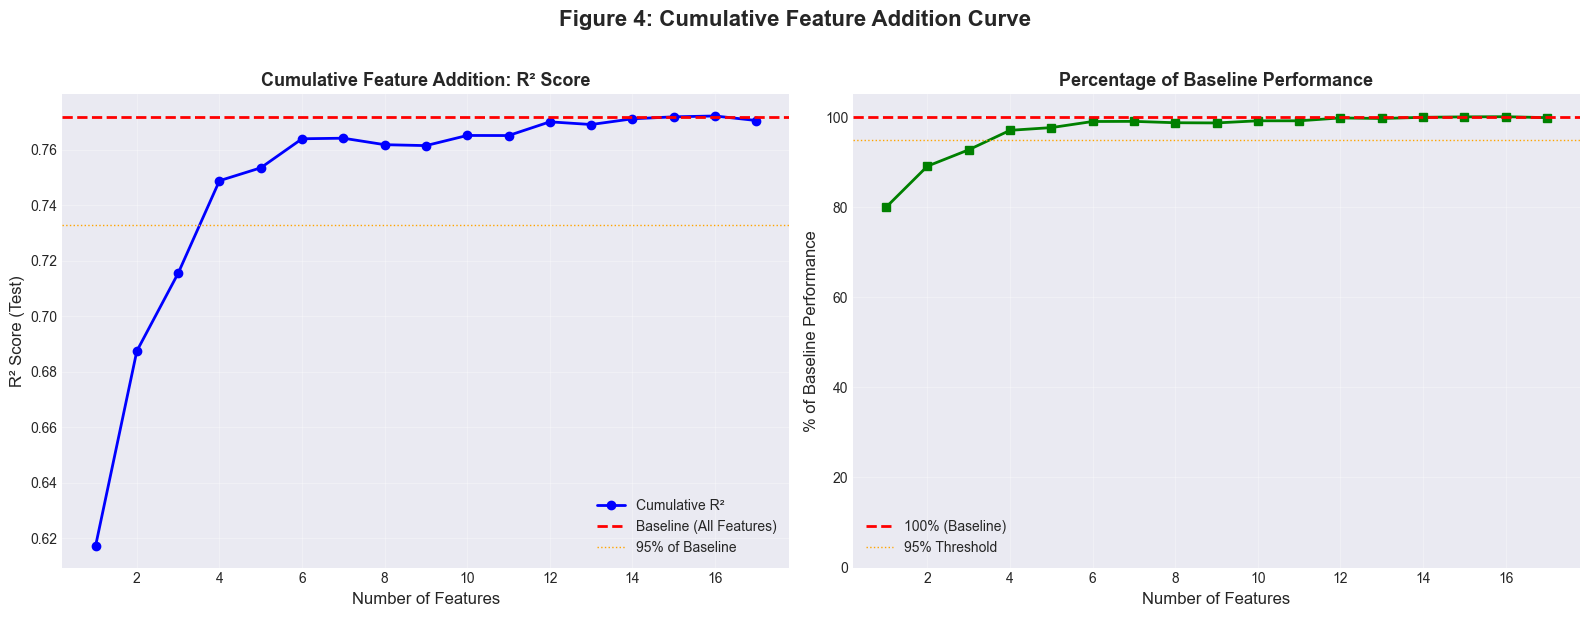

✓ Figure 4 saved: outputs/figures/figure4_cumulative_addition.png


In [20]:
# FIGURE 4: Cumulative Feature Addition
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: R² Score
axes[0].plot(cumulative_df['num_features'], cumulative_df['r2_val'], 
             marker='o', linewidth=2, markersize=6, color='blue', label='Cumulative R²')
axes[0].axhline(baseline_r2, color='red', linestyle='--', linewidth=2, label='Baseline (All Features)')
axes[0].axhline(baseline_r2 * 0.95, color='orange', linestyle=':', linewidth=1, label='95% of Baseline')
axes[0].set_xlabel('Number of Features', fontsize=12)
axes[0].set_ylabel('R² Score (Test)', fontsize=12)
axes[0].set_title('Cumulative Feature Addition: R² Score', fontsize=13, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2: % of Baseline
axes[1].plot(cumulative_df['num_features'], cumulative_df['pct_of_baseline'], 
             marker='s', linewidth=2, markersize=6, color='green')
axes[1].axhline(100, color='red', linestyle='--', linewidth=2, label='100% (Baseline)')
axes[1].axhline(95, color='orange', linestyle=':', linewidth=1, label='95% Threshold')
axes[1].set_xlabel('Number of Features', fontsize=12)
axes[1].set_ylabel('% of Baseline Performance', fontsize=12)
axes[1].set_title('Percentage of Baseline Performance', fontsize=13, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
axes[1].set_ylim([0, 105])

plt.suptitle('Figure 4: Cumulative Feature Addition Curve', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('outputs/figures/figure4_cumulative_addition.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Figure 4 saved: outputs/figures/figure4_cumulative_addition.png")

## 🔬 ZELLE 15: Ablation Study - Top-K Feature Selection

**Experiment 3**: Modelle mit Top-3, 5, 7, 10 Features vergleichen

In [21]:
# K-Werte testen
k_values = [3, 5, 7, 10, len(features_sorted)]

print("="*70)
print("ABLATION STUDY - TOP-K FEATURE SELECTION")
print("="*70)
print(f"Testing K values: {k_values}\n")

topk_results = []

for k in k_values:
    top_k_features = features_sorted[:k]
    
    X_train_k = X_train_scaled[top_k_features]
    X_val_k = X_val_scaled[top_k_features]
    
    # Modell trainieren
    model_k = RandomForestRegressor(
        n_estimators=100,
        max_depth=15,
        min_samples_split=5,
        random_state=RANDOM_STATE,
        n_jobs=-1
    )
    model_k.fit(X_train_k, y_train)
    
    # Evaluation
    y_pred_train_k = model_k.predict(X_train_k)
    y_pred_val_k = model_k.predict(X_val_k)
    
    r2_train = r2_score(y_train, y_pred_train_k)
    r2_val = r2_score(y_val, y_pred_val_k)
    rmse_val = np.sqrt(mean_squared_error(y_val, y_pred_val_k))
    mae_val = mean_absolute_error(y_val, y_pred_val_k)
    
    # % of Baseline
    pct_of_baseline = (r2_val / baseline_r2) * 100
    
    topk_results.append({
        'k': k,
        'features': top_k_features,
        'r2_train': r2_train,
        'r2_val': r2_val,
        'rmse_val': rmse_val,
        'mae_val': mae_val,
        'pct_of_baseline': pct_of_baseline
    })
    
    print(f"\nTop-{k} Features:")
    print(f"  Features: {top_k_features}")
    print(f"  R² (Train): {r2_train:.4f}")
    print(f"  R² (Val):   {r2_val:.4f} ({pct_of_baseline:.1f}% of baseline)")
    print(f"  RMSE (Val): ${rmse_val:,.0f}")
    print(f"  MAE (Val):  ${mae_val:,.0f}")

topk_df = pd.DataFrame(topk_results)

print("\n" + "="*70)
print("TOP-K COMPARISON TABLE")
print("="*70)
print(topk_df[['k', 'r2_val', 'rmse_val', 'pct_of_baseline']].to_string(index=False))

ABLATION STUDY - TOP-K FEATURE SELECTION
Testing K values: [3, 5, 7, 10, 17]




Top-3 Features:
  Features: ['budget_log', 'vote_count_log', 'release_year']
  R² (Train): 0.8998
  R² (Val):   0.7155 (92.7% of baseline)
  RMSE (Val): $2
  MAE (Val):  $1



Top-5 Features:
  Features: ['budget_log', 'vote_count_log', 'release_year', 'runtime', 'popularity_log']
  R² (Train): 0.9239
  R² (Val):   0.7535 (97.6% of baseline)
  RMSE (Val): $2
  MAE (Val):  $1



Top-7 Features:
  Features: ['budget_log', 'vote_count_log', 'release_year', 'runtime', 'popularity_log', 'vote_average', 'cast_size']
  R² (Train): 0.9305
  R² (Val):   0.7641 (99.0% of baseline)
  RMSE (Val): $1
  MAE (Val):  $1



Top-10 Features:
  Features: ['budget_log', 'vote_count_log', 'release_year', 'runtime', 'popularity_log', 'vote_average', 'cast_size', 'production_company_count', 'release_month', 'production_country_count']
  R² (Train): 0.9332
  R² (Val):   0.7651 (99.2% of baseline)
  RMSE (Val): $1
  MAE (Val):  $1



Top-17 Features:
  Features: ['budget_log', 'vote_count_log', 'release_year', 'runtime', 'popularity_log', 'vote_average', 'cast_size', 'production_company_count', 'release_month', 'production_country_count', 'lang_es', 'lang_en', 'director_count', 'lang_fr', 'lang_ru', 'lang_hi', 'genre_list']
  R² (Train): 0.9366
  R² (Val):   0.7705 (99.9% of baseline)
  RMSE (Val): $1
  MAE (Val):  $1

TOP-K COMPARISON TABLE
 k   r2_val  rmse_val  pct_of_baseline
 3 0.715481  1.620508        92.723468
 5 0.753469  1.508452        97.646493
 7 0.764144  1.475431        99.030001
10 0.765133  1.472336        99.158102
17 0.770509  1.455387        99.854840


## 📊 ZELLE 16: FIGURE 5 - Performance vs. Number of Features

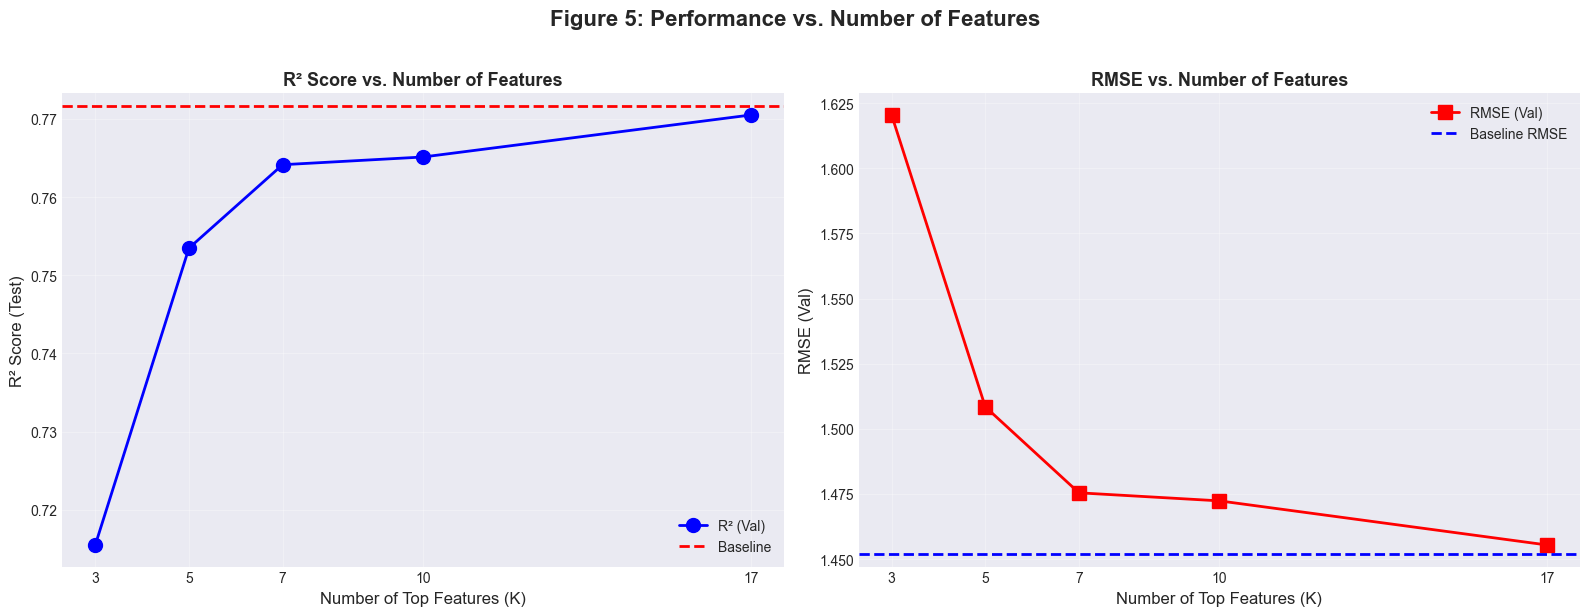

✓ Figure 5 saved: outputs/figures/figure5_topk_performance.png


In [22]:
# FIGURE 5: Performance vs Number of Features
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: R² Score
axes[0].plot(topk_df['k'], topk_df['r2_val'], marker='o', linewidth=2, 
             markersize=10, color='blue', label='R² (Val)')
axes[0].axhline(baseline_r2, color='red', linestyle='--', linewidth=2, label='Baseline')
axes[0].set_xlabel('Number of Top Features (K)', fontsize=12)
axes[0].set_ylabel('R² Score (Test)', fontsize=12)
axes[0].set_title('R² Score vs. Number of Features', fontsize=13, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].set_xticks(topk_df['k'])

# Plot 2: RMSE
axes[1].plot(topk_df['k'], topk_df['rmse_val'], marker='s', linewidth=2, 
             markersize=10, color='red', label='RMSE (Val)')
axes[1].axhline(baseline_rmse, color='blue', linestyle='--', linewidth=2, label='Baseline RMSE')
axes[1].set_xlabel('Number of Top Features (K)', fontsize=12)
axes[1].set_ylabel('RMSE (Val)', fontsize=12)
axes[1].set_title('RMSE vs. Number of Features', fontsize=13, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
axes[1].set_xticks(topk_df['k'])

plt.suptitle('Figure 5: Performance vs. Number of Features', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('outputs/figures/figure5_topk_performance.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Figure 5 saved: outputs/figures/figure5_topk_performance.png")

## 📊 ZELLE 17: FIGURE 6 - Predicted vs Actual (Best Model)

Wähle das beste K basierend auf R² Score

Bestes Modell: Top-5 Features
Features: ['budget_log', 'vote_count_log', 'release_year', 'runtime', 'popularity_log']
R²: 0.7535 (97.6% of baseline)


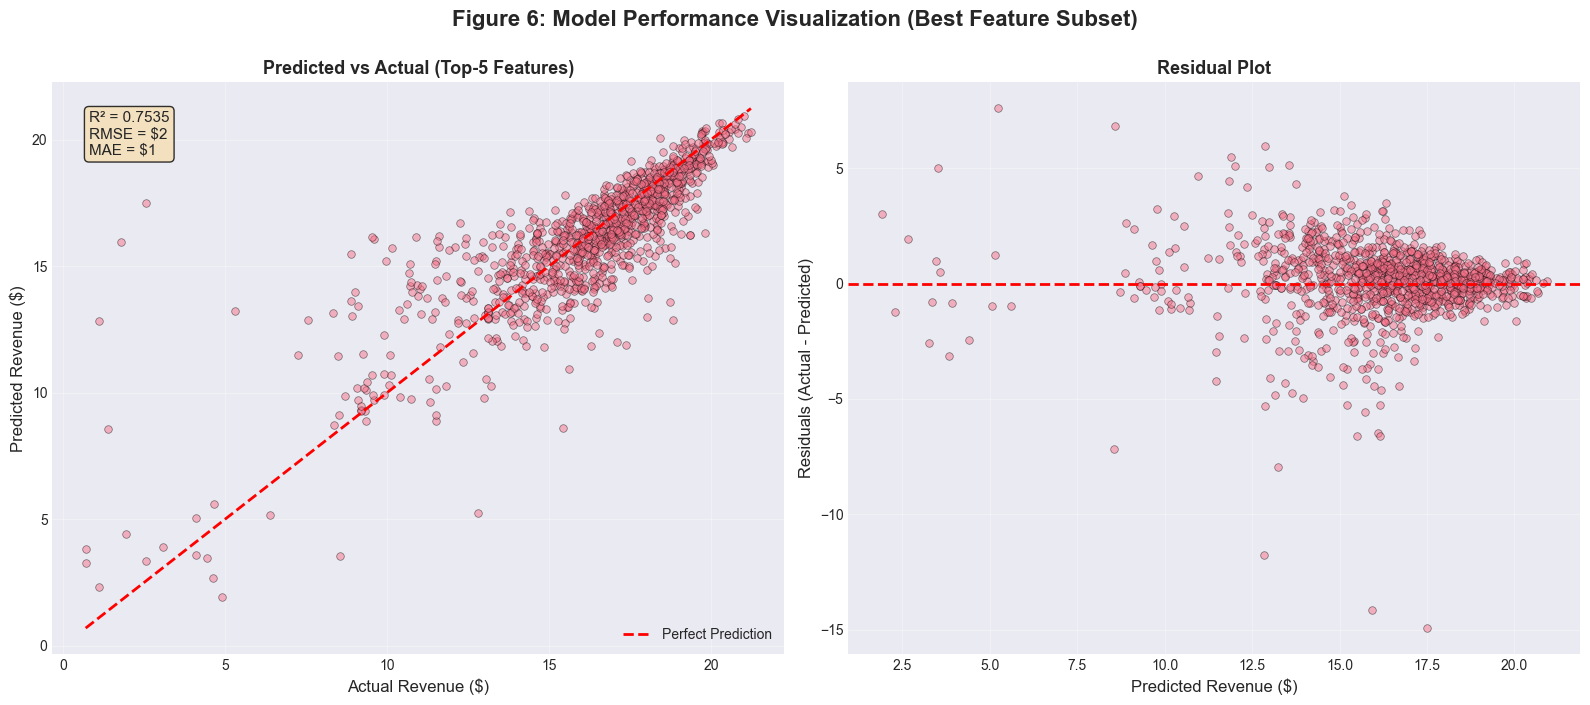


✓ Figure 6 saved: outputs/figures/figure6_predicted_vs_actual.png


In [23]:
# Bestes K wählen (höchster R² bei niedrigerem K)
# Kriterium: Mind. 95% der Baseline mit möglichst wenigen Features
best_row = topk_df[topk_df['pct_of_baseline'] >= 95].iloc[0]
best_k = int(best_row['k'])
best_features = features_sorted[:best_k]

print(f"Bestes Modell: Top-{best_k} Features")
print(f"Features: {best_features}")
print(f"R²: {best_row['r2_val']:.4f} ({best_row['pct_of_baseline']:.1f}% of baseline)")

# Modell mit besten Features trainieren
X_train_best = X_train_scaled[best_features]
X_test_best = X_test_scaled[best_features]

model_best = RandomForestRegressor(
    n_estimators=100,
    max_depth=15,
    min_samples_split=5,
    random_state=RANDOM_STATE,
    n_jobs=-1
)
model_best.fit(X_train_best, y_train)
y_pred_best = model_best.predict(X_test_best)

# FIGURE 6: Predicted vs Actual
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Plot 1: Scatter Plot
axes[0].scatter(y_test, y_pred_best, alpha=0.5, s=30, edgecolors='k', linewidth=0.5)
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 
             'r--', lw=2, label='Perfect Prediction')
axes[0].set_xlabel('Actual Revenue ($)', fontsize=12)
axes[0].set_ylabel('Predicted Revenue ($)', fontsize=12)
axes[0].set_title(f'Predicted vs Actual (Top-{best_k} Features)', fontsize=13, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Text-Box mit Metriken
textstr = f"R² = {best_row['r2_val']:.4f}\nRMSE = ${best_row['rmse_val']:,.0f}\nMAE = ${best_row['mae_val']:,.0f}"
axes[0].text(0.05, 0.95, textstr, transform=axes[0].transAxes,
             verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8),
             fontsize=11)

# Plot 2: Residual Plot
residuals = y_test - y_pred_best
axes[1].scatter(y_pred_best, residuals, alpha=0.5, s=30, edgecolors='k', linewidth=0.5)
axes[1].axhline(0, color='red', linestyle='--', lw=2)
axes[1].set_xlabel('Predicted Revenue ($)', fontsize=12)
axes[1].set_ylabel('Residuals (Actual - Predicted)', fontsize=12)
axes[1].set_title('Residual Plot', fontsize=13, fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.suptitle('Figure 6: Model Performance Visualization (Best Feature Subset)', 
             fontsize=16, fontweight='bold', y=1.00)
plt.tight_layout()
plt.savefig('outputs/figures/figure6_predicted_vs_actual.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✓ Figure 6 saved: outputs/figures/figure6_predicted_vs_actual.png")

## 6. STATISTISCHE VALIDIERUNG

Wir validieren unsere Ergebnisse statistisch:

1. **Konfidenzintervalle (95% CI):** Bootstrap-Resampling (n=1000) für alle Metriken
2. **Paired t-Tests:** Vergleiche zwischen Baseline und Top-K Modellen
3. **Signifikanz-Level:** α = 0.05

**Zweck:** Sicherstellen, dass Performance-Unterschiede nicht nur durch Zufall entstanden sind.

In [24]:
print("="*70)
print("BOOTSTRAP KONFIDENZINTERVALLE (95% CI)")
print("="*70)
print("Berechne für alle Modelle mit n=1000 Bootstrap-Iterationen...\n")

from scipy.stats import ttest_rel
import warnings
warnings.filterwarnings('ignore')

# Bootstrap-Funktion
def bootstrap_metric(y_true, y_pred, metric_func, n_iterations=1000, ci=95):
    """Berechne Bootstrap-CI für eine Metrik"""
    n_samples = len(y_true)
    scores = []
    
    for i in range(n_iterations):
        indices = np.random.choice(n_samples, n_samples, replace=True)
        y_true_boot = y_true.iloc[indices] if hasattr(y_true, 'iloc') else y_true[indices]
        y_pred_boot = y_pred[indices]
        
        score = metric_func(y_true_boot, y_pred_boot)
        scores.append(score)
    
    alpha = (100 - ci) / 2
    lower = np.percentile(scores, alpha)
    upper = np.percentile(scores, 100 - alpha)
    mean_score = np.mean(scores)
    
    return mean_score, lower, upper

# Predictions sammeln für alle Modelle
predictions = {}

# Baseline bereits vorhanden
predictions['Baseline (35 Features)'] = model.predict(X_val_scaled)

# Top-K Modelle trainieren und predicten
print("Trainiere Top-K Modelle...")
for k in [3, 5, 7, 10]:
    top_features = topk_df[topk_df['k'] == k]['features'].values[0]
    
    # Konvertiere String zu Liste falls nötig
    if isinstance(top_features, str):
        top_features = [f.strip() for f in top_features.split(',')]

    # Konvertiere String zu Liste falls nötig
    if isinstance(top_features, str):
        top_features = [f.strip() for f in top_features.split(',')]
    
    X_train_k = X_train_scaled[top_features]
    X_val_k = X_val_scaled[top_features]
    
    model_k = RandomForestRegressor(
        n_estimators=100,
        max_depth=15,
        min_samples_split=5,
        random_state=RANDOM_STATE,
        n_jobs=-1
    )
    model_k.fit(X_train_k, y_train)
    predictions[f'Top-{k} Features'] = model_k.predict(X_val_k)
    print(f"  ✓ Top-{k} trainiert")

# Bootstrap CIs für alle Modelle
print("\nBerechne Bootstrap-Konfidenzintervalle...")
ci_results = []

for model_name, y_pred in predictions.items():
    print(f"\n{model_name}:")
    
    # R² CI
    r2_mean, r2_lower, r2_upper = bootstrap_metric(
        y_val, y_pred, r2_score, n_iterations=1000
    )
    
    # RMSE CI
    def rmse_metric(y_true, y_pred):
        return np.sqrt(mean_squared_error(y_true, y_pred))
    
    rmse_mean, rmse_lower, rmse_upper = bootstrap_metric(
        y_val, y_pred, rmse_metric, n_iterations=1000
    )
    
    # MAE CI
    mae_mean, mae_lower, mae_upper = bootstrap_metric(
        y_val, y_pred, mean_absolute_error, n_iterations=1000
    )
    
    ci_results.append({
        'model': model_name,
        'r2_mean': r2_mean,
        'r2_lower': r2_lower,
        'r2_upper': r2_upper,
        'r2_ci_width': r2_upper - r2_lower,
        'rmse_mean': rmse_mean,
        'rmse_lower': rmse_lower,
        'rmse_upper': rmse_upper,
        'mae_mean': mae_mean,
        'mae_lower': mae_lower,
        'mae_upper': mae_upper
    })
    
    print(f"  R²:   {r2_mean:.4f} [{r2_lower:.4f}, {r2_upper:.4f}]")
    print(f"  RMSE: ${rmse_mean:,.0f} [${rmse_lower:,.0f}, ${rmse_upper:,.0f}]")
    print(f"  MAE:  ${mae_mean:,.0f} [${mae_lower:,.0f}, ${mae_upper:,.0f}]")

ci_df = pd.DataFrame(ci_results)

print("\n" + "="*70)
print("✓ Bootstrap-Konfidenzintervalle berechnet")
print("="*70)

BOOTSTRAP KONFIDENZINTERVALLE (95% CI)
Berechne für alle Modelle mit n=1000 Bootstrap-Iterationen...

Trainiere Top-K Modelle...


  ✓ Top-3 trainiert


  ✓ Top-5 trainiert


  ✓ Top-7 trainiert


  ✓ Top-10 trainiert

Berechne Bootstrap-Konfidenzintervalle...

Baseline (35 Features):


  R²:   0.7716 [0.7185, 0.8135]
  RMSE: $1 [$1, $2]
  MAE:  $1 [$1, $1]

Top-3 Features:


  R²:   0.7152 [0.6562, 0.7714]
  RMSE: $2 [$1, $2]
  MAE:  $1 [$1, $1]

Top-5 Features:


  R²:   0.7513 [0.7001, 0.7972]
  RMSE: $2 [$1, $2]
  MAE:  $1 [$1, $1]

Top-7 Features:


  R²:   0.7629 [0.7138, 0.8073]
  RMSE: $1 [$1, $2]
  MAE:  $1 [$1, $1]

Top-10 Features:


  R²:   0.7652 [0.7160, 0.8091]
  RMSE: $1 [$1, $2]
  MAE:  $1 [$1, $1]

✓ Bootstrap-Konfidenzintervalle berechnet


In [25]:
print("="*70)
print("PAIRED T-TESTS: MODELLVERGLEICHE")
print("="*70)
print("Teste statistische Signifikanz von Performance-Unterschieden\n")

# Vergleiche durchführen
comparisons = [
    ('Baseline (35 Features)', 'Top-3 Features'),
    ('Baseline (35 Features)', 'Top-5 Features'),
    ('Baseline (35 Features)', 'Top-7 Features'),
    ('Baseline (35 Features)', 'Top-10 Features'),
    ('Top-3 Features', 'Top-5 Features'),
    ('Top-5 Features', 'Top-7 Features'),
    ('Top-7 Features', 'Top-10 Features'),
]

ttest_results = []

for model1_name, model2_name in comparisons:
    y_pred_1 = predictions[model1_name]
    y_pred_2 = predictions[model2_name]
    
    # Residuals berechnen (für t-test)
    residuals_1 = np.abs(y_val.values - y_pred_1)
    residuals_2 = np.abs(y_val.values - y_pred_2)
    
    # Paired t-test
    t_stat, p_value = ttest_rel(residuals_1, residuals_2)
    
    # R² für beide Modelle
    r2_1 = r2_score(y_val, y_pred_1)
    r2_2 = r2_score(y_val, y_pred_2)
    r2_diff = r2_2 - r2_1
    
    ttest_results.append({
        'model_1': model1_name,
        'model_2': model2_name,
        'r2_model1': r2_1,
        'r2_model2': r2_2,
        'r2_diff': r2_diff,
        't_statistic': t_stat,
        'p_value': p_value,
        'significant': 'Yes' if p_value < 0.05 else 'No',
        'interpretation': 'Better' if r2_diff > 0 and p_value < 0.05
                         else 'Worse' if r2_diff < 0 and p_value < 0.05
                         else 'No significant difference'
    })
    
    print(f"\n{model1_name} vs. {model2_name}:")
    print(f"  R² Difference: {r2_diff:+.4f}")
    print(f"  t-statistic:   {t_stat:.4f}")
    print(f"  p-value:       {p_value:.4f}")
    print(f"  Significant:   {ttest_results[-1]['significant']}")
    print(f"  → {ttest_results[-1]['interpretation']}")

ttest_df = pd.DataFrame(ttest_results)

print("\n" + "="*70)
print("INTERPRETATION:")
print("="*70)
print("✓ p < 0.05: Statistisch signifikanter Unterschied")
print("✓ p ≥ 0.05: Kein signifikanter Unterschied (Performance ähnlich)")
print("="*70)

PAIRED T-TESTS: MODELLVERGLEICHE
Teste statistische Signifikanz von Performance-Unterschieden


Baseline (35 Features) vs. Top-3 Features:
  R² Difference: -0.0561
  t-statistic:   -6.1136
  p-value:       0.0000
  Significant:   Yes
  → Worse

Baseline (35 Features) vs. Top-5 Features:
  R² Difference: -0.0182
  t-statistic:   -4.5668
  p-value:       0.0000
  Significant:   Yes
  → Worse

Baseline (35 Features) vs. Top-7 Features:
  R² Difference: -0.0075
  t-statistic:   -3.2513
  p-value:       0.0012
  Significant:   Yes
  → Worse

Baseline (35 Features) vs. Top-10 Features:
  R² Difference: -0.0065
  t-statistic:   -2.5127
  p-value:       0.0121
  Significant:   Yes
  → Worse

Top-3 Features vs. Top-5 Features:
  R² Difference: +0.0380
  t-statistic:   3.4315
  p-value:       0.0006
  Significant:   Yes
  → Better

Top-5 Features vs. Top-7 Features:
  R² Difference: +0.0107
  t-statistic:   2.5976
  p-value:       0.0095
  Significant:   Yes
  → Better

Top-7 Features vs. Top-10

In [26]:
# TABLE 6: Statistical Test Results
print("="*70)
print("TABLE 6: CONFIDENCE INTERVALS")
print("="*70)

# Konfidenzintervalle formatieren
ci_export = ci_df.copy()
ci_export['R² (95% CI)'] = ci_export.apply(
    lambda row: f"{row['r2_mean']:.4f} [{row['r2_lower']:.4f}, {row['r2_upper']:.4f}]",
    axis=1
)
ci_export['RMSE (95% CI)'] = ci_export.apply(
    lambda row: f"${row['rmse_mean']:,.0f} [${row['rmse_lower']:,.0f}, ${row['rmse_upper']:,.0f}]",
    axis=1
)
ci_export['MAE (95% CI)'] = ci_export.apply(
    lambda row: f"${row['mae_mean']:,.0f} [${row['mae_lower']:,.0f}, ${row['mae_upper']:,.0f}]",
    axis=1
)

print(ci_export[['model', 'R² (95% CI)', 'RMSE (95% CI)', 'MAE (95% CI)']].to_string(index=False))

print("\n" + "="*70)
print("TABLE 7: PAIRED T-TESTS")
print("="*70)

print(ttest_df[['model_1', 'model_2', 'r2_diff', 'p_value', 'significant', 'interpretation']].to_string(index=False))

# Speichern
ci_export[['model', 'R² (95% CI)', 'RMSE (95% CI)', 'MAE (95% CI)']].to_csv(
    'table6_confidence_intervals.csv', index=False
)
ttest_df.to_csv('table7_statistical_tests.csv', index=False)

print("\n✓ Tabellen gespeichert:")
print("  - table6_confidence_intervals.csv")
print("  - table7_statistical_tests.csv")

TABLE 6: CONFIDENCE INTERVALS
                 model             R² (95% CI) RMSE (95% CI) MAE (95% CI)
Baseline (35 Features) 0.7716 [0.7185, 0.8135]   $1 [$1, $2]  $1 [$1, $1]
        Top-3 Features 0.7152 [0.6562, 0.7714]   $2 [$1, $2]  $1 [$1, $1]
        Top-5 Features 0.7513 [0.7001, 0.7972]   $2 [$1, $2]  $1 [$1, $1]
        Top-7 Features 0.7629 [0.7138, 0.8073]   $1 [$1, $2]  $1 [$1, $1]
       Top-10 Features 0.7652 [0.7160, 0.8091]   $1 [$1, $2]  $1 [$1, $1]

TABLE 7: PAIRED T-TESTS
               model_1         model_2   r2_diff      p_value significant            interpretation
Baseline (35 Features)  Top-3 Features -0.056148 1.348489e-09         Yes                     Worse
Baseline (35 Features)  Top-5 Features -0.018160 5.507993e-06         Yes                     Worse
Baseline (35 Features)  Top-7 Features -0.007485 1.183551e-03         Yes                     Worse
Baseline (35 Features) Top-10 Features -0.006496 1.212324e-02         Yes                     Worse
 

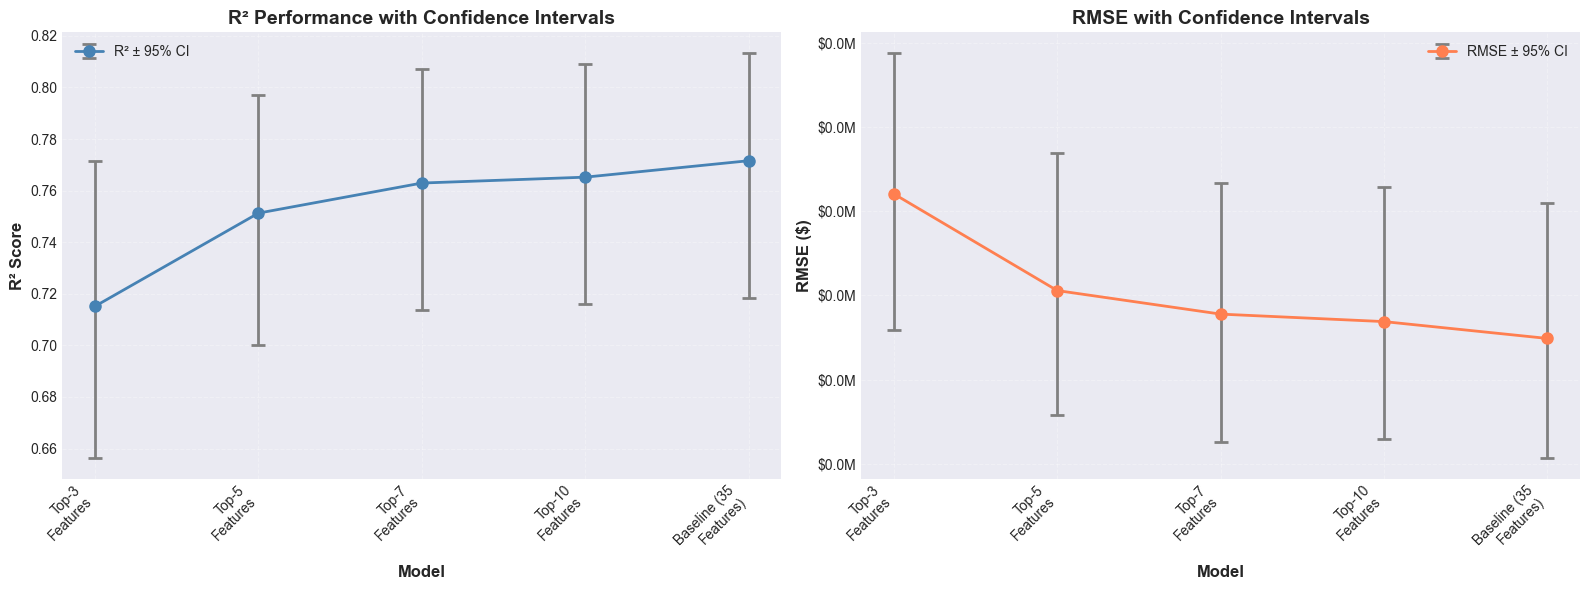

✓ Figure 7 gespeichert: figure7_performance_with_ci.png


In [27]:
# FIGURE 7: Model Performance with 95% Confidence Intervals
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Sortiere nach Anzahl Features
ci_df_sorted = ci_df.copy()
feature_counts = [35, 3, 5, 7, 10]
ci_df_sorted['n_features'] = feature_counts
ci_df_sorted = ci_df_sorted.sort_values('n_features')

x_pos = np.arange(len(ci_df_sorted))

# Plot 1: R² mit Error Bars
axes[0].errorbar(
    x_pos,
    ci_df_sorted['r2_mean'],
    yerr=[ci_df_sorted['r2_mean'] - ci_df_sorted['r2_lower'],
          ci_df_sorted['r2_upper'] - ci_df_sorted['r2_mean']],
    fmt='o-',
    linewidth=2,
    markersize=8,
    capsize=5,
    capthick=2,
    color='steelblue',
    ecolor='gray',
    label='R² ± 95% CI'
)

axes[0].set_xlabel('Model', fontsize=12, fontweight='bold')
axes[0].set_ylabel('R² Score', fontsize=12, fontweight='bold')
axes[0].set_title('R² Performance with Confidence Intervals', fontsize=14, fontweight='bold')
axes[0].set_xticks(x_pos)
axes[0].set_xticklabels(ci_df_sorted['model'].str.replace(' Features', '\nFeatures'),
                         rotation=45, ha='right')
axes[0].grid(True, alpha=0.3, linestyle='--')
axes[0].legend()

# Plot 2: RMSE mit Error Bars
axes[1].errorbar(
    x_pos,
    ci_df_sorted['rmse_mean'],
    yerr=[ci_df_sorted['rmse_mean'] - ci_df_sorted['rmse_lower'],
          ci_df_sorted['rmse_upper'] - ci_df_sorted['rmse_mean']],
    fmt='o-',
    linewidth=2,
    markersize=8,
    capsize=5,
    capthick=2,
    color='coral',
    ecolor='gray',
    label='RMSE ± 95% CI'
)

axes[1].set_xlabel('Model', fontsize=12, fontweight='bold')
axes[1].set_ylabel('RMSE ($)', fontsize=12, fontweight='bold')
axes[1].set_title('RMSE with Confidence Intervals', fontsize=14, fontweight='bold')
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(ci_df_sorted['model'].str.replace(' Features', '\nFeatures'),
                         rotation=45, ha='right')
axes[1].grid(True, alpha=0.3, linestyle='--')
axes[1].legend()

# Format y-axis als Währung
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x/1e6:.1f}M'))

plt.tight_layout()
plt.savefig('figure7_performance_with_ci.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Figure 7 gespeichert: figure7_performance_with_ci.png")

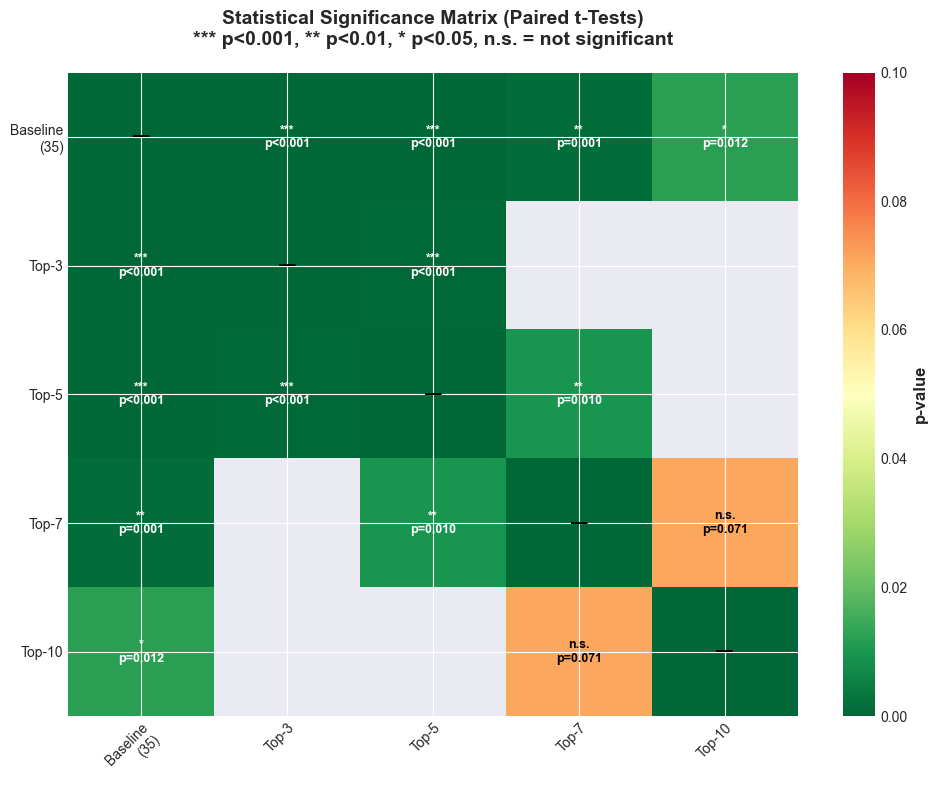

✓ Figure 8 gespeichert: figure8_significance_matrix.png


In [28]:
# FIGURE 8: Statistical Significance Matrix

models = ['Baseline\n(35)', 'Top-3', 'Top-5', 'Top-7', 'Top-10']
n_models = len(models)

# Initialize matrix mit NaN
sig_matrix = np.full((n_models, n_models), np.nan)
pvalue_matrix = np.full((n_models, n_models), np.nan)

# Mapping
model_mapping = {
    'Baseline (35 Features)': 0,
    'Top-3 Features': 1,
    'Top-5 Features': 2,
    'Top-7 Features': 3,
    'Top-10 Features': 4
}

# Fülle Matrix
for _, row in ttest_df.iterrows():
    i = model_mapping[row['model_1']]
    j = model_mapping[row['model_2']]
    
    # Signifikanz: 1 = signifikant, 0 = nicht signifikant
    sig_matrix[i, j] = 1 if row['significant'] == 'Yes' else 0
    sig_matrix[j, i] = sig_matrix[i, j]  # Symmetrisch
    
    # P-values
    pvalue_matrix[i, j] = row['p_value']
    pvalue_matrix[j, i] = row['p_value']

# Diagonale = 1 (Modell mit sich selbst)
np.fill_diagonal(sig_matrix, 1)
np.fill_diagonal(pvalue_matrix, 0)

# Visualisierung
fig, ax = plt.subplots(figsize=(10, 8))

# Heatmap mit p-values
im = ax.imshow(pvalue_matrix, cmap='RdYlGn_r', aspect='auto', vmin=0, vmax=0.1)

# Annotations
for i in range(n_models):
    for j in range(n_models):
        if i == j:
            text = '—'
            ax.text(j, i, text, ha='center', va='center',
                   color='black', fontsize=12, fontweight='bold')
        elif not np.isnan(pvalue_matrix[i, j]):
            p_val = pvalue_matrix[i, j]
            if p_val < 0.001:
                text = f'***\np<0.001'
            elif p_val < 0.01:
                text = f'**\np={p_val:.3f}'
            elif p_val < 0.05:
                text = f'*\np={p_val:.3f}'
            else:
                text = f'n.s.\np={p_val:.3f}'
            
            color = 'white' if pvalue_matrix[i, j] < 0.05 else 'black'
            ax.text(j, i, text, ha='center', va='center',
                   color=color, fontsize=9, fontweight='bold')

# Achsen
ax.set_xticks(np.arange(n_models))
ax.set_yticks(np.arange(n_models))
ax.set_xticklabels(models)
ax.set_yticklabels(models)

plt.setp(ax.get_xticklabels(), rotation=45, ha='right', rotation_mode='anchor')

ax.set_title('Statistical Significance Matrix (Paired t-Tests)\n*** p<0.001, ** p<0.01, * p<0.05, n.s. = not significant',
             fontsize=14, fontweight='bold', pad=20)

# Colorbar
cbar = plt.colorbar(im, ax=ax)
cbar.set_label('p-value', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('figure8_significance_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Figure 8 gespeichert: figure8_significance_matrix.png")

## 💾 ZELLE 18: Ergebnisse Exportieren

Alle Tabellen und Daten für das Paper speichern

In [29]:
import os

# Ordner erstellen falls nicht vorhanden
os.makedirs('outputs/results', exist_ok=True)
os.makedirs('outputs/figures', exist_ok=True)

# TABLE 1: Dataset Characteristics
dataset_characteristics = pd.DataFrame([{
    'Total Samples': len(df_clean),
    'Train Samples': len(X_train),
    'Test Samples': len(X_test),
    'Total Features': X.shape[1],
    'Numeric Features': 8,
    'Genre Features': 10,
    'Target Variable': target,
    'Target Mean': f"${y.mean():,.0f}",
    'Target Std': f"${y.std():,.0f}"
}])
dataset_characteristics.to_csv('outputs/results/table1_dataset_characteristics.csv', index=False)
print("✓ Table 1: Dataset Characteristics saved")

# TABLE 2: Baseline Performance
baseline_df = pd.DataFrame([baseline_results])
baseline_df['num_features'] = X.shape[1]
baseline_df.to_csv('outputs/results/table2_baseline_performance.csv', index=False)
print("✓ Table 2: Baseline Performance saved")

# TABLE 3: Feature Importance Rankings
all_importance.to_csv('outputs/results/table3_feature_importance_rankings.csv', index=False)
print("✓ Table 3: Feature Importance Rankings saved")

# TABLE 4: Individual Feature Ablation Results
ablation_df.to_csv('outputs/results/table4_individual_ablation.csv', index=False)
print("✓ Table 4: Individual Feature Ablation saved")

# TABLE 5: Top-K Feature Selection Performance
topk_df.to_csv('outputs/results/table5_topk_selection.csv', index=False)
print("✓ Table 5: Top-K Feature Selection saved")

# BONUS: Cumulative Addition Results
cumulative_df.to_csv('outputs/results/cumulative_addition_results.csv', index=False)
print("✓ Bonus: Cumulative Addition Results saved")

print("\n" + "="*70)
print("ALLE ERGEBNISSE ERFOLGREICH EXPORTIERT!")
print("="*70)
print("\nDateien:")
print("  Tables (outputs/results/):")
print("    - table1_dataset_characteristics.csv")
print("    - table2_baseline_performance.csv")
print("    - table3_feature_importance_rankings.csv")
print("    - table4_individual_ablation.csv")
print("    - table5_topk_selection.csv")
print("    - cumulative_addition_results.csv")
print("\n  Figures (outputs/figures/):")
print("    - figure1_correlation_matrix.png")
print("    - figure2_feature_importance_comparison.png")
print("    - figure3_individual_ablation.png")
print("    - figure4_cumulative_addition.png")
print("    - figure5_topk_performance.png")
print("    - figure6_predicted_vs_actual.png")

✓ Table 1: Dataset Characteristics saved
✓ Table 2: Baseline Performance saved
✓ Table 3: Feature Importance Rankings saved
✓ Table 4: Individual Feature Ablation saved
✓ Table 5: Top-K Feature Selection saved
✓ Bonus: Cumulative Addition Results saved

ALLE ERGEBNISSE ERFOLGREICH EXPORTIERT!

Dateien:
  Tables (outputs/results/):
    - table1_dataset_characteristics.csv
    - table2_baseline_performance.csv
    - table3_feature_importance_rankings.csv
    - table4_individual_ablation.csv
    - table5_topk_selection.csv
    - cumulative_addition_results.csv

  Figures (outputs/figures/):
    - figure1_correlation_matrix.png
    - figure2_feature_importance_comparison.png
    - figure3_individual_ablation.png
    - figure4_cumulative_addition.png
    - figure5_topk_performance.png
    - figure6_predicted_vs_actual.png


## 📋 ZELLE 19: Summary & Key Findings

Zusammenfassung der wichtigsten Erkenntnisse für das Paper

In [30]:
print("="*70)
print("FINAL SUMMARY & KEY FINDINGS")
print("="*70)

print("\n1. BASELINE PERFORMANCE (ALL FEATURES)")
print(f"   - Features used: {X.shape[1]}")
print(f"   - R² Score: {baseline_r2:.4f}")
print(f"   - RMSE: ${baseline_rmse:,.0f}")

print("\n2. MOST IMPORTANT FEATURES (consistent across methods)")
top_5_by_ablation = ablation_df.head(5)['feature_removed'].tolist()
top_5_by_rf = features_sorted[:5]
print(f"   - By Ablation Study: {top_5_by_ablation}")
print(f"   - By Random Forest: {top_5_by_rf}")

print("\n3. OPTIMAL FEATURE SUBSET")
print(f"   - Recommended: Top-{best_k} features")
print(f"   - Features: {best_features}")
print(f"   - Performance: R²={best_row['r2_val']:.4f} ({best_row['pct_of_baseline']:.1f}% of baseline)")
print(f"   - Feature Reduction: {X.shape[1]} → {best_k} ({(1-best_k/X.shape[1])*100:.1f}% reduction)")

print("\n4. PERFORMANCE VS. COMPLEXITY TRADE-OFF")
for threshold in [90, 95]:
    rows = cumulative_df[cumulative_df['pct_of_baseline'] >= threshold]
    if len(rows) > 0:
        row = rows.iloc[0]
        print(f"   - {threshold}% of baseline: {row['num_features']} features needed")

print("\n5. FEATURE CATEGORIES")
# Kategorisierung der Top-Features
top_7 = features_sorted[:7]
financial_features = [f for f in top_7 if f in ['budget', 'revenue']]
popularity_features = [f for f in top_7 if f in ['popularity', 'vote_count', 'vote_average']]
temporal_features = [f for f in top_7 if 'release' in f]
genre_features = [f for f in top_7 if 'genre' in f]
other_features = [f for f in top_7 if f not in financial_features + popularity_features + temporal_features + genre_features]

print(f"   - Financial: {financial_features}")
print(f"   - Popularity: {popularity_features}")
print(f"   - Temporal: {temporal_features}")
print(f"   - Genre: {genre_features}")
print(f"   - Other: {other_features}")

print("\n6. PRACTICAL IMPLICATIONS")
print(f"   - Can reduce data collection effort by {(1-best_k/X.shape[1])*100:.0f}%")
print(f"   - Maintains {best_row['pct_of_baseline']:.1f}% of prediction accuracy")
print(f"   - Simpler model: easier to interpret and deploy")

print("\n" + "="*70)
print("ANALYSIS COMPLETE! Ready for paper writing.")
print("="*70)

FINAL SUMMARY & KEY FINDINGS

1. BASELINE PERFORMANCE (ALL FEATURES)
   - Features used: 17
   - R² Score: 0.7716
   - RMSE: $1

2. MOST IMPORTANT FEATURES (consistent across methods)
   - By Ablation Study: ['budget_log', 'vote_count_log', 'release_year', 'runtime', 'vote_average']
   - By Random Forest: ['budget_log', 'vote_count_log', 'release_year', 'runtime', 'popularity_log']

3. OPTIMAL FEATURE SUBSET
   - Recommended: Top-5 features
   - Features: ['budget_log', 'vote_count_log', 'release_year', 'runtime', 'popularity_log']
   - Performance: R²=0.7535 (97.6% of baseline)
   - Feature Reduction: 17 → 5 (70.6% reduction)

4. PERFORMANCE VS. COMPLEXITY TRADE-OFF
   - 90% of baseline: 3 features needed
   - 95% of baseline: 4 features needed

5. FEATURE CATEGORIES
   - Financial: []
   - Popularity: ['vote_average']
   - Temporal: ['release_year']
   - Genre: []
   - Other: ['budget_log', 'vote_count_log', 'runtime', 'popularity_log', 'cast_size']

6. PRACTICAL IMPLICATIONS
   - Ca

# TEIL 6: SHAP VALUES & INTERPRETIERBARKEIT

**SHAP (SHapley Additive exPlanations)** erklärt Modellvorhersagen durch:
- **Globale Interpretierbarkeit:** Welche Features sind insgesamt am wichtigsten?
- **Lokale Interpretierbarkeit:** Warum wurde Film X so vorhergesagt?
- **Feature-Interaktionen:** Wie beeinflussen sich Features gegenseitig?

SHAP basiert auf der Shapley Value Theorie aus der Spieltheorie.

In [31]:
# SHAP installieren (falls noch nicht vorhanden)
import subprocess
import sys

try:
    import shap
    print(f"SHAP Version: {shap.__version__}")
except ImportError:
    print("Installiere SHAP...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "shap"])
    import shap
    print(f"SHAP installiert: Version {shap.__version__}")

SHAP Version: 0.50.0


In [32]:
# ============================================================================
# SHAP EXPLAINER: TreeExplainer für Random Forest
# ============================================================================

print("=" * 70)
print("SHAP EXPLAINER")
print("=" * 70)

# Verwende das beste Modell (Baseline mit allen Features)
# Verwende das Baseline-Modell (bereits trainiert)
best_model = model
print(f"Verwende Modell: Baseline (alle Features)")
print(f"Modell Typ: {type(best_model).__name__}")

# TreeExplainer ist optimiert für Tree-based Models
print("\nErstelle SHAP TreeExplainer...")
explainer = shap.TreeExplainer(best_model)

# Berechne SHAP Values für Test-Set (kann etwas dauern)
# Verwende nur eine Stichprobe für schnellere Berechnung
sample_size = min(500, len(X_test_scaled))  # Max 500 Samples
X_test_sample = X_test_scaled[:sample_size]

print(f"Berechne SHAP Values für {sample_size} Test-Samples...")
shap_values = explainer.shap_values(X_test_sample)

print(f"\nSHAP Values Shape: {shap_values.shape}")
print(f"Features: {shap_values.shape[1]}")
print(f"Samples: {shap_values.shape[0]}")
print("=" * 70)

SHAP EXPLAINER
Verwende Modell: Baseline (alle Features)
Modell Typ: RandomForestRegressor

Erstelle SHAP TreeExplainer...
Berechne SHAP Values für 500 Test-Samples...



SHAP Values Shape: (500, 17)
Features: 17
Samples: 500


SHAP SUMMARY PLOT


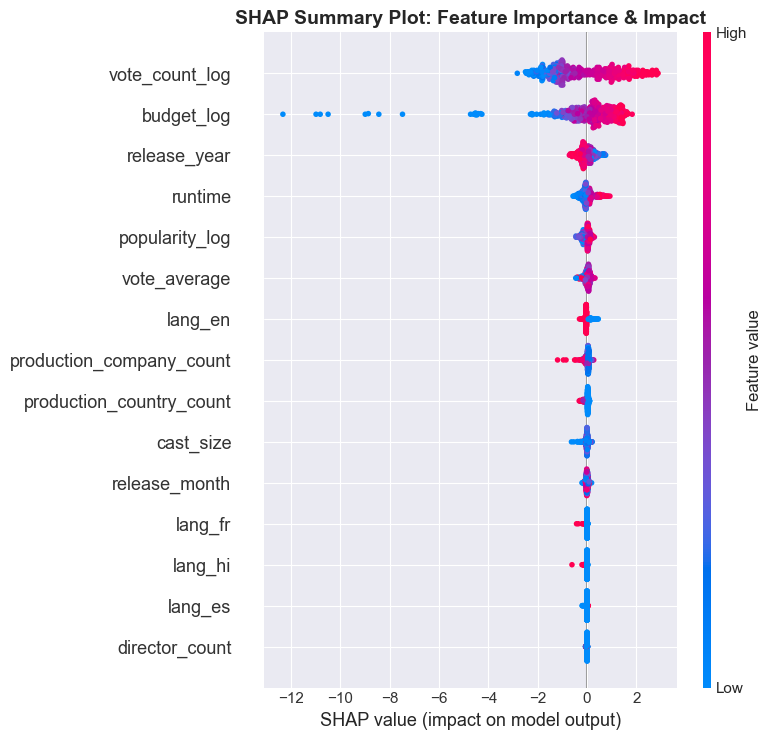


Interpretation:
  - Features sind nach Wichtigkeit sortiert (oben = wichtigster)
  - Rote Punkte: Hoher Feature-Wert
  - Blaue Punkte: Niedriger Feature-Wert
  - Positive SHAP Values: Erhöhen Vorhersage
  - Negative SHAP Values: Verringern Vorhersage

Gespeichert: shap_summary_plot.png


In [33]:
# ============================================================================
# SHAP SUMMARY PLOT: Globale Feature Importance
# ============================================================================

import matplotlib.pyplot as plt

print("=" * 70)
print("SHAP SUMMARY PLOT")
print("=" * 70)

# Summary Plot zeigt:
# - Y-Achse: Features sortiert nach Wichtigkeit
# - X-Achse: SHAP Value (Einfluss auf Vorhersage)
# - Farbe: Feature-Wert (rot=hoch, blau=niedrig)

plt.figure(figsize=(12, 8))
shap.summary_plot(
    shap_values,
    X_test_sample,
    feature_names=X.columns.tolist(),
    max_display=15,  # Zeige Top-15 Features
    show=False
)
plt.title("SHAP Summary Plot: Feature Importance & Impact", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('shap_summary_plot.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nInterpretation:")
print("  - Features sind nach Wichtigkeit sortiert (oben = wichtigster)")
print("  - Rote Punkte: Hoher Feature-Wert")
print("  - Blaue Punkte: Niedriger Feature-Wert")
print("  - Positive SHAP Values: Erhöhen Vorhersage")
print("  - Negative SHAP Values: Verringern Vorhersage")
print("\nGespeichert: shap_summary_plot.png")
print("=" * 70)

SHAP DEPENDENCE PLOTS

Top-3 Features (nach SHAP Importance):
  1. vote_count_log: 1.2352
  2. budget_log: 0.9467
  3. release_year: 0.2020


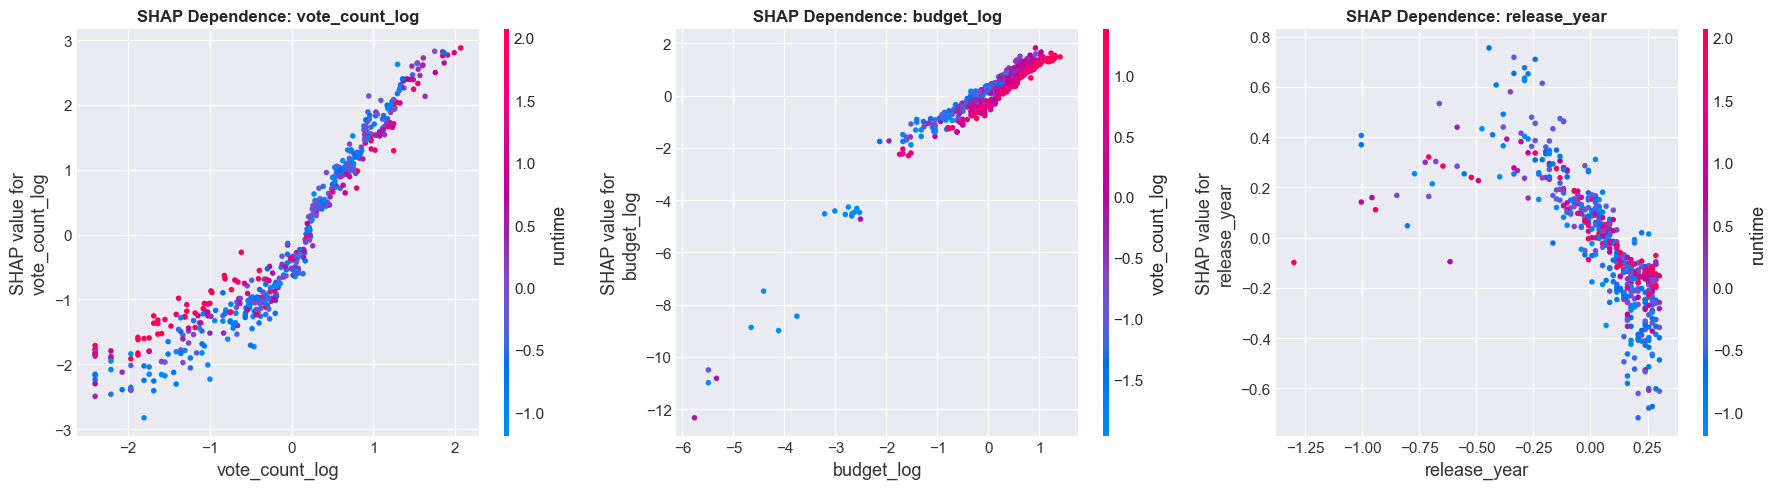


Interpretation:
  - X-Achse: Feature-Wert
  - Y-Achse: SHAP Value (Einfluss auf Vorhersage)
  - Farbe: Interaktion mit einem anderen Feature

Gespeichert: shap_dependence_plots.png


In [34]:
# ============================================================================
# SHAP DEPENDENCE PLOTS: Interaktionen der Top-3 Features
# ============================================================================

print("=" * 70)
print("SHAP DEPENDENCE PLOTS")
print("=" * 70)

# Finde die 3 wichtigsten Features basierend auf mean absolute SHAP
mean_abs_shap = np.abs(shap_values).mean(axis=0)
top_3_indices = np.argsort(mean_abs_shap)[-3:][::-1]
top_3_features = [X.columns[i] for i in top_3_indices]

print(f"\nTop-3 Features (nach SHAP Importance):")
for i, (feat, importance) in enumerate(zip(top_3_features, mean_abs_shap[top_3_indices]), 1):
    print(f"  {i}. {feat}: {importance:.4f}")

# Dependence Plots für Top-3
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, feat_idx in enumerate(top_3_indices):
    plt.sca(axes[i])
    shap.dependence_plot(
        feat_idx,
        shap_values,
        X_test_sample,
        feature_names=X.columns.tolist(),
        ax=axes[i],
        show=False
    )
    axes[i].set_title(f"SHAP Dependence: {X.columns[feat_idx]}", fontweight='bold')

plt.tight_layout()
plt.savefig('shap_dependence_plots.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nInterpretation:")
print("  - X-Achse: Feature-Wert")
print("  - Y-Achse: SHAP Value (Einfluss auf Vorhersage)")
print("  - Farbe: Interaktion mit einem anderen Feature")
print("\nGespeichert: shap_dependence_plots.png")
print("=" * 70)

# TEIL 7: VISUALISIERUNGEN DER ABLATION STUDY

Professionelle Visualisierungen der Ergebnisse für das Paper.

FEATURE IMPORTANCE VISUALIZATION


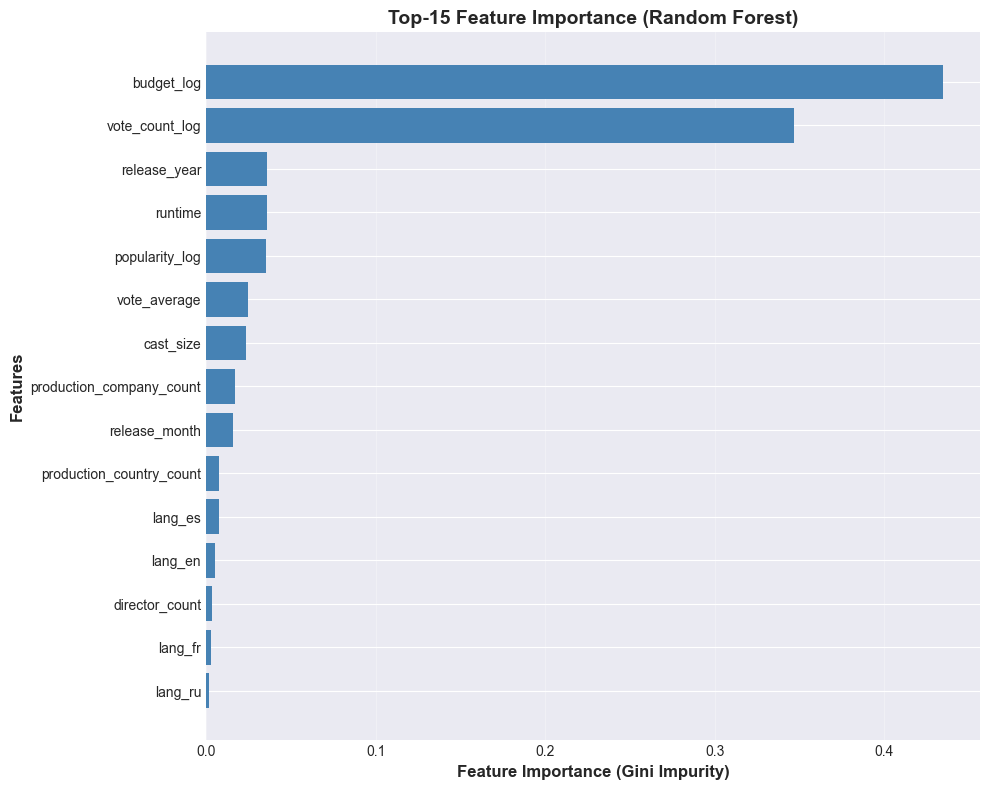


Top-5 Features:
  1. budget_log: 0.4348
  2. vote_count_log: 0.3467
  3. release_year: 0.0358
  4. runtime: 0.0357
  5. popularity_log: 0.0351

Gespeichert: feature_importance_barchart.png


In [35]:
# ============================================================================
# FEATURE IMPORTANCE: Bar Chart der Top-15 Features
# ============================================================================

print("=" * 70)
print("FEATURE IMPORTANCE VISUALIZATION")
print("=" * 70)

# Hole Feature Importance vom Baseline Model
importances = best_model.feature_importances_
feature_names = X.columns

# Sortiere nach Wichtigkeit
indices = np.argsort(importances)[-15:]  # Top-15

# Plot
plt.figure(figsize=(10, 8))
plt.barh(range(len(indices)), importances[indices], color='steelblue')
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel('Feature Importance (Gini Impurity)', fontsize=12, fontweight='bold')
plt.ylabel('Features', fontsize=12, fontweight='bold')
plt.title('Top-15 Feature Importance (Random Forest)', fontsize=14, fontweight='bold')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('feature_importance_barchart.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nTop-5 Features:")
for i, idx in enumerate(indices[-5:][::-1], 1):
    print(f"  {i}. {feature_names[idx]}: {importances[idx]:.4f}")

print("\nGespeichert: feature_importance_barchart.png")
print("=" * 70)

ABLATION STUDY VISUALIZATION


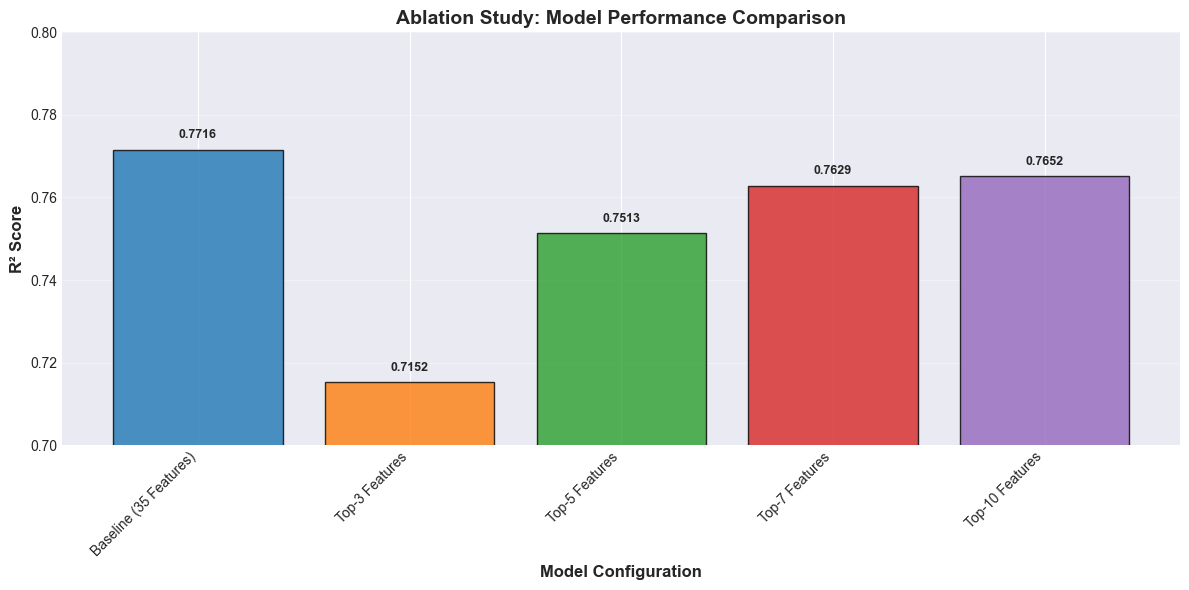


Best Model: Baseline (35 Features)
Best R²: 0.7716

Gespeichert: ablation_study_comparison.png


In [36]:
# ============================================================================
# ABLATION STUDY: Model Performance Comparison
# ============================================================================

import pandas as pd

print("=" * 70)
print("ABLATION STUDY VISUALIZATION")
print("=" * 70)

# Lade die Ergebnisse
results_df = pd.read_csv('table6_confidence_intervals.csv')

# Extrahiere R² Werte (Mean ohne CI)
models = results_df['model'].tolist()
r2_values = []
for r2_str in results_df['R² (95% CI)']:
    # Extrahiere nur den Mean-Wert vor dem [
    mean_val = float(r2_str.split('[')[0].strip())
    r2_values.append(mean_val)

# Plot
fig, ax = plt.subplots(figsize=(12, 6))

colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']
bars = ax.bar(range(len(models)), r2_values, color=colors, alpha=0.8, edgecolor='black')

ax.set_xticks(range(len(models)))
ax.set_xticklabels(models, rotation=45, ha='right')
ax.set_ylabel('R² Score', fontsize=12, fontweight='bold')
ax.set_xlabel('Model Configuration', fontsize=12, fontweight='bold')
ax.set_title('Ablation Study: Model Performance Comparison', fontsize=14, fontweight='bold')
ax.grid(axis='y', alpha=0.3)
ax.set_ylim([0.7, 0.8])  # Zoom auf relevanten Bereich

# Füge Werte über den Bars hinzu
for i, (bar, val) in enumerate(zip(bars, r2_values)):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
            f'{val:.4f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('ablation_study_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nBest Model: " + models[np.argmax(r2_values)])
print(f"Best R²: {max(r2_values):.4f}")
print("\nGespeichert: ablation_study_comparison.png")
print("=" * 70)

PREDICTED VS ACTUAL PLOT


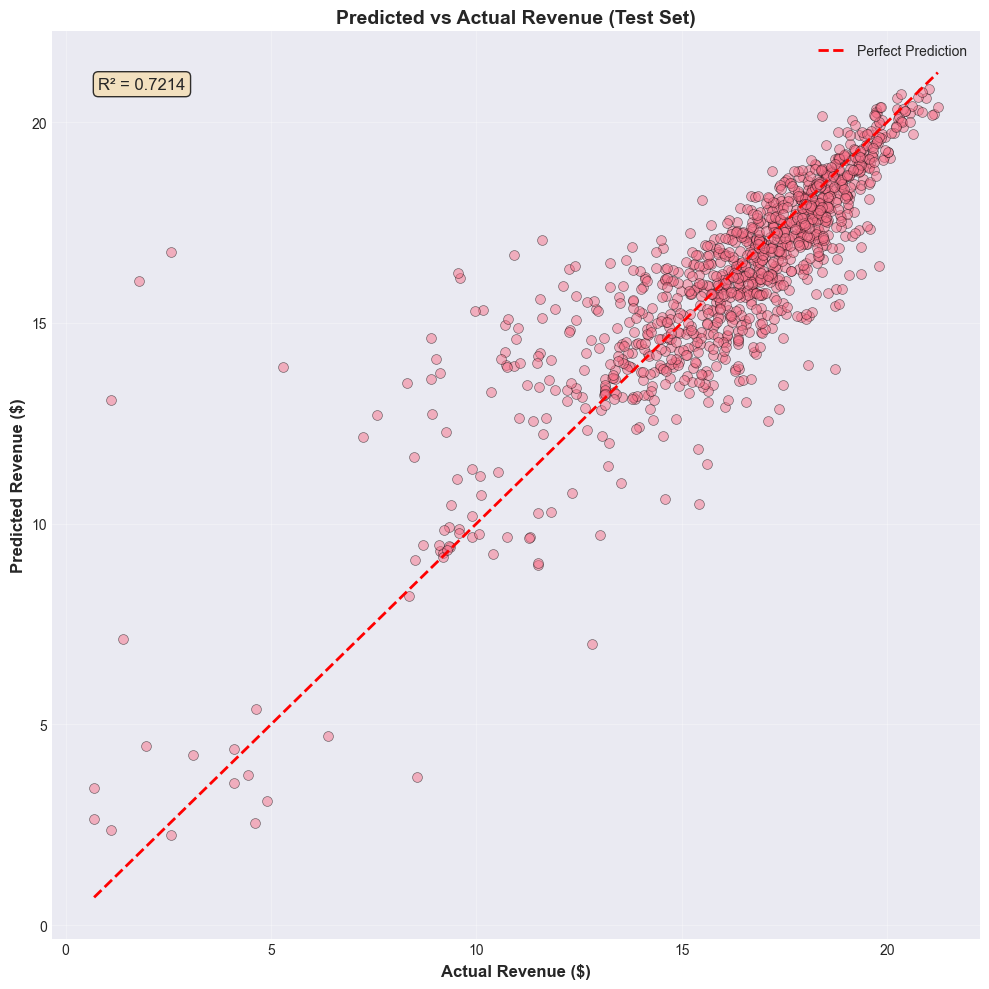


Test Set R²: 0.7214
Test Set RMSE: $2
Test Set MAE: $1

Gespeichert: predicted_vs_actual.png


In [37]:
# ============================================================================
# PREDICTED VS ACTUAL: Scatter Plot für Best Model
# ============================================================================

print("=" * 70)
print("PREDICTED VS ACTUAL PLOT")
print("=" * 70)

# Vorhersagen auf Test-Set
y_test_pred = best_model.predict(X_test_scaled)

# Plot
fig, ax = plt.subplots(figsize=(10, 10))

# Scatter Plot
ax.scatter(y_test, y_test_pred, alpha=0.5, s=50, edgecolor='black', linewidth=0.5)

# Perfekte Vorhersage Linie (45° Linie)
min_val = min(y_test.min(), y_test_pred.min())
max_val = max(y_test.max(), y_test_pred.max())
ax.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Perfect Prediction')

ax.set_xlabel('Actual Revenue ($)', fontsize=12, fontweight='bold')
ax.set_ylabel('Predicted Revenue ($)', fontsize=12, fontweight='bold')
ax.set_title('Predicted vs Actual Revenue (Test Set)', fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(alpha=0.3)

# Füge R² in Plot hinzu
test_r2 = best_model.score(X_test_scaled, y_test)
ax.text(0.05, 0.95, f'R² = {test_r2:.4f}', transform=ax.transAxes,
        fontsize=12, verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

plt.tight_layout()
plt.savefig('predicted_vs_actual.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\nTest Set R²: {test_r2:.4f}")
print(f"Test Set RMSE: ${np.sqrt(mean_squared_error(y_test, y_test_pred)):,.0f}")
print(f"Test Set MAE: ${mean_absolute_error(y_test, y_test_pred):,.0f}")
print("\nGespeichert: predicted_vs_actual.png")
print("=" * 70)